# ICMS 150 (June 1 experiment)

- Closed loop plan: day 1: perform visual (16 orientations, 100 trials) and electrical (3000 patterns, 50 oracles x 20 trials). This notebook is used after output spike sorting and curation to fit stimulus-encoder TCN model and generate stimualtion patterns for each orientation to try on day 2. 


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 50 oracle samples repeating 20 times


In [1]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2
datadir = "data/icms_150_6_2_26"
mode = "lda"

all_spikes = np.load(f"{datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json(f"{datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load(f"{datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load(f"{datadir}/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()

In [2]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
trial_labels = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 63, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 63, 50)


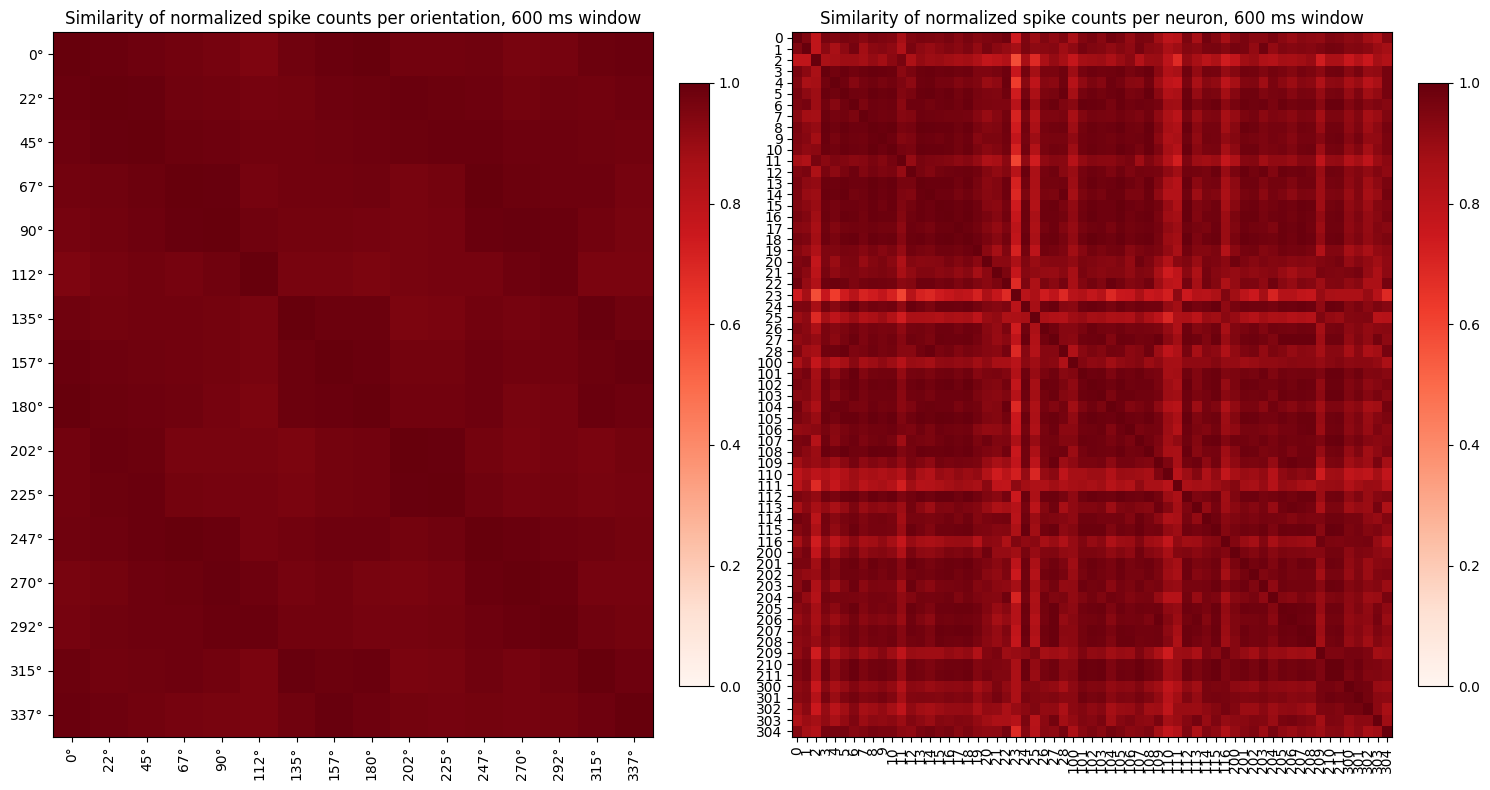

In [ ]:
from sklearn.preprocessing import normalize
window = 600 # ms
orient_total = sum_responses[:, :, :window // 10].sum(axis=2)  # (n_orient, n_neurons)
normed_ori = normalize(orient_total, norm='l2')  # each row independently        # (16, n_neurons)
sim_matrix_ori = normed_ori @ normed_ori.T     

normed_neuron = normalize(orient_total.T, norm='l2').T  # each column independently      
sim_matrix_neuron = normed_neuron.T @ normed_neuron

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
im = ax[0].imshow(sim_matrix_ori, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[0].set_xticks(range(len(visual_orientation_degs)))
ax[0].set_yticks(range(len(visual_orientation_degs)))
ax[0].set_xticklabels([f'{int(d)}°' for d in visual_orientation_degs], rotation=90)
ax[0].set_yticklabels([f'{int(d)}°' for d in visual_orientation_degs])
ax[0].set_title(f'Similarity of normalized spike counts per orientation, {window} ms window')

ax[1].set_title(f'Similarity of normalized spike counts per neuron, {window} ms window')
ax[1].imshow(sim_matrix_neuron, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[1].set_xticks(range(n_neurons))
ax[1].set_yticks(range(n_neurons))
ax[1].set_xticklabels(all_neuron_ids, rotation=90)
ax[1].set_yticklabels(all_neuron_ids)   
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

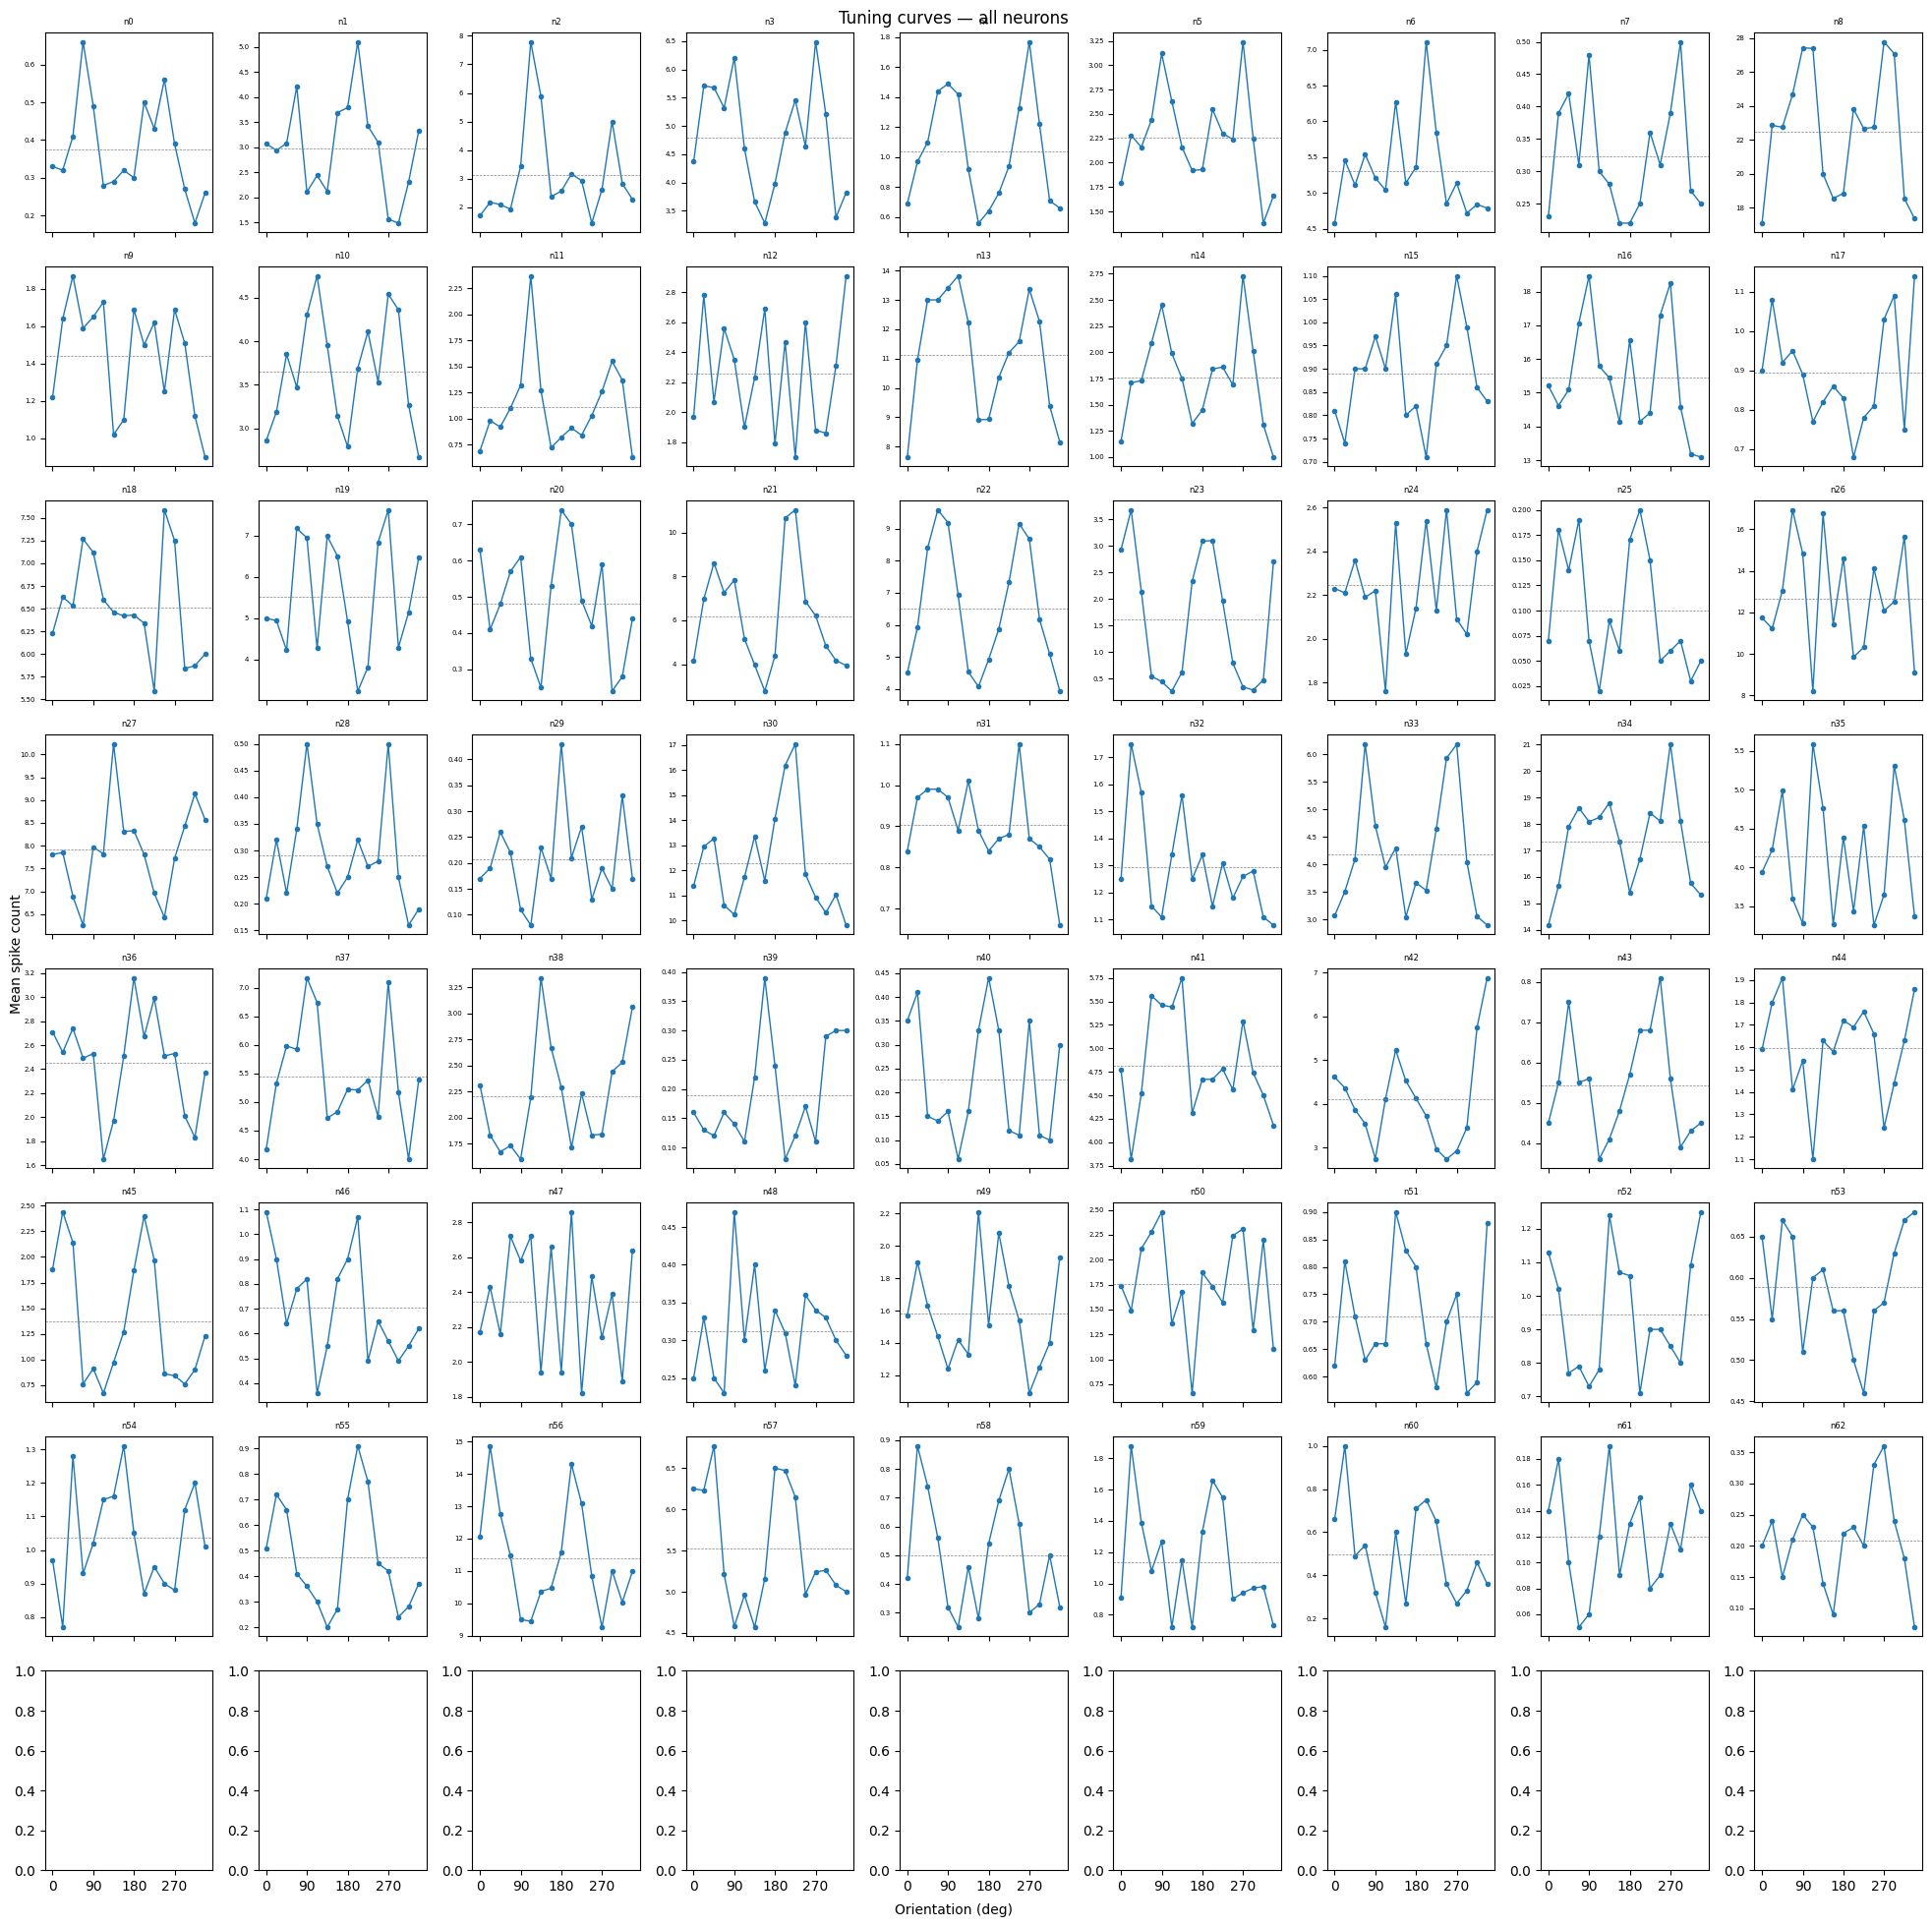

In [5]:
# Tuning curves: mean spike count per orientation, per neuron
fig, axes = plt.subplots(8, 9, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, nidx in enumerate(range(63)):
    ax = axes[i]
    ax.plot(visual_orientation_degs, orient_total[:, nidx], 'o-', ms=3, lw=1)
    ax.axhline(orient_total[:, nidx].mean(), color='gray', lw=0.5, linestyle='--')
    ax.set_title(f'n{nidx}', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_xticks(visual_orientation_degs[::4])

for ax in axes[len(range(72)):]:
    ax.set_visible(False)

fig.supxlabel('Orientation (deg)', fontsize=10)
fig.supylabel('Mean spike count', fontsize=10)
fig.suptitle(f'Tuning curves — all neurons', fontsize=12)
plt.tight_layout()
plt.show()


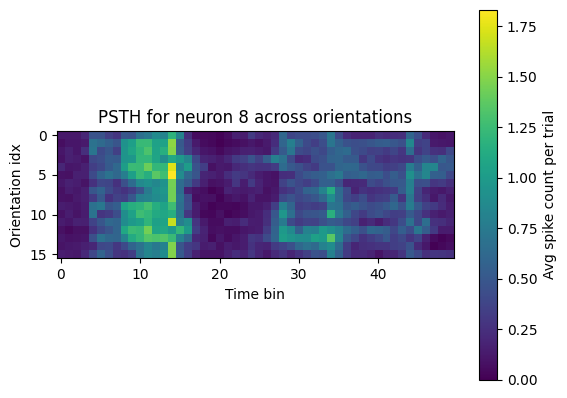

In [6]:
n_idx = 8
plt.imshow(sum_responses[:, n_idx, :])
plt.ylabel("Orientation idx")
plt.xlabel("Time bin")
plt.title(f"PSTH for neuron {n_idx} across orientations")
plt.colorbar(label="Avg spike count per trial")
plt.show()

In [7]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
mean_vec = X.mean(axis=0, keepdims=True)


# 1. Extract raw trial counts and labels to fit LDA
vis_window_samples = (600 * SAMPLE_RATE) // 1000
trial_raw_counts = []
trial_labels = []

for orientation in visual_orientation_degs:
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_raw_counts.append(x_trial)
        trial_labels.append(orientation)

trial_raw_counts = np.array(trial_raw_counts)
trial_labels = np.array(trial_labels)

# 2. Fit LDA to visual trials
# LDA requires categorical labels, so we map orientations to strings
lda_labels = trial_labels.astype(str)

# (Using n_components=2 to match PC plot)
lda = LDA(n_components=2)
lda.fit(trial_raw_counts, lda_labels)

if mode == "pca":
    pca3 = PCA(n_components=2)
    pca3.fit(X)
    proj, _ = np.linalg.qr(np.array([
        mean_vec[0],
        pca3.components_[0],
        pca3.components_[1],
    ]).T)        
    print ("PCA explained variance ratio:", pca3.explained_variance_ratio_)
elif mode == "lda":
    proj, _ = np.linalg.qr(np.array([
        mean_vec[0],
        lda.scalings_[:, 0],
        lda.scalings_[:, 1],
    ]).T)
    print ("LDA explained variance ratio:", lda.explained_variance_ratio_)
else:
    raise ValueError(f"Unknown mode: {mode}")

coords = X @ proj                           # (n_orientations, 3)  -- averaged points

# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    name='Individual trials',
    hovertemplate='trial<extra></extra>',
    showlegend=True,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Orientation average',
))
if mode == "pca":
    fig.update_layout(title='Average Neural Responses to Visual Stimuli (PCA Projection)')
    fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
elif mode == "lda":
    fig.update_layout(title='Average Neural Responses to Visual Stimuli (LDA Projection)')
    fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='LDA1', zaxis_title='LDA2',
               aspectmode='data'),
    width=800, height=700,  
)
fig.show()


LDA explained variance ratio: [0.32570063 0.29912481]


In [ ]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Compute 2D Projections
if mode == "pca":
    X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
    mean_vec = X.mean(axis=0, keepdims=True)
    pca2 = PCA(n_components=2)
    pca2.fit(X)

    coords = X @ pca3.components_.T                           # (n_orientations, 3)  -- averaged points
elif mode == "lda":
    X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
    mean_vec = X.mean(axis=0, keepdims=True)
    coords = X @ lda.scalings_                     # (n_orientations, 3)  -- averaged points
else:
    raise ValueError(f"Unknown mode: {mode}")
# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        if mode == "pca":
            trial_coords.append(x_trial @ pca2.components_.T)
        elif mode == "lda":
            trial_coords.append(x_trial @ lda.scalings_)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter(
    x=trial_coords[:, 0], y=trial_coords[:, 1],
    mode='markers',
    marker=dict(size=5, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    hovertemplate='trial<extra></extra>',
    showlegend=False,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter(
    x=coords[:, 0], y=coords[:, 1], 
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='',
    showlegend=False,
))

if mode == "pca":
    fig.update_layout(title='Trial-averaged Neural Responses to Oriented Visual Stimuli (PCA Projection)')
    fig.update_layout(
    title='Trial-averaged Neural Responses to Oriented Visual Stimuli',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
    )
    fig.write_html('results/vis_response_pc1_pc2.html', include_plotlyjs='cdn')
    fig.write_image('results/vis_response_pc1_pc2.svg', width=800, height=700, scale=2)

elif mode == "lda":
    fig.update_layout(title='Trial-averaged Neural Responses to Oriented Visual Stimuli (LDA Projection)')
    fig.update_layout(
    title='Trial-averaged Neural Responses to Oriented Visual Stimuli',
    scene=dict(xaxis_title='LDA1', yaxis_title='LDA2',
               aspectmode='data'),
    width=800, height=700,
)   
fig.show()




In [9]:
# make a categorical vector of length (1, channels x amplitudes) 1-hot encoded). 
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
pattern_df_raw = read_pattern_json(f'{datadir}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
n_amplitudes = 2 # +- 3 uA
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 720
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
train_indices = non_oracle_timing
test_indices  = oracle_timing


Stim channels: 40, Neurons: 63
Unique patterns: 3050, Total trials: 4000


In [10]:
# ============================================================
# Prepare stim->spike datasets + loaders for model evaluation.
#   - inputs : per-electrode current ('current' encoding), 10 ms bins, +-3 amps
#   - targets: per-neuron spike counts, 10 ms bins
#   - train  : non-oracle trials (90/10 train/val split)
#   - test   : oracle trials
#   - stim channels only (no init state, no spike history)
#
# NOTE: the model is no longer trained here -- it is selected by the
# hyperparameter-optimization cell below (`best_model`). This cell only
# builds the datasets/loaders and the loss used to score the model.
# ============================================================
import os, sys, json, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils  import BinnedStimSpikeDataset
from models import SimpleCausalSpikeCNN

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print('device:', device)

# Base binning config. Architecture/training hyperparameters are chosen by
# the HP-opt cell; `CFG` is overwritten there from the winning trial.
MAX_TIME_MS = 600
CFG = dict(
    INPUT_BIN_MS  = 10,
    OUTPUT_BIN_MS = 10,
    N_INPUT_BINS  = MAX_TIME_MS // 10,
    N_OUTPUT_BINS = MAX_TIME_MS // 10,
    MAX_TIME_MS   = MAX_TIME_MS,
    ENCODING_MODE = 'current',
    BATCH_SIZE    = 16,
    VAL_FRAC      = 0.2,
    SEED          = 42,
)

# --- datasets (non-oracle -> train+val, oracle -> test) ---
torch.manual_seed(CFG['SEED']); np.random.seed(CFG['SEED'])

train_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=train_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)
test_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=test_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)

# 90/10 train/val split of the non-oracle set.
n_total = len(train_ds)
perm = np.random.RandomState(CFG['SEED']).permutation(n_total)
n_val = max(1, int(n_total * CFG['VAL_FRAC']))
val_idx, tr_idx = perm[:n_val].tolist(), perm[n_val:].tolist()

# encoding_mode='current' returns int64 amplitudes (+-3); the model expects floats
# when the embedding layer is disabled. Cast in collate_fn.
def _float_collate(batch):
    xs = torch.stack([torch.as_tensor(b[0]).float() for b in batch])
    ys = torch.stack([torch.as_tensor(b[1]).float() for b in batch])
    return xs, ys

NUM_WORKERS = 0  # avoid macOS spawn pickling issues with cell-local collate fn
train_loader = DataLoader(Subset(train_ds, tr_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=True, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(Subset(train_ds, val_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'], shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
print(f'train: {len(tr_idx)}  val: {len(val_idx)}  test: {len(test_ds)}')

# Loss used to score the selected model on held-out oracle trials.
base_criterion = nn.PoissonNLLLoss(log_input=True, full=True, reduction='none')


device: cuda
0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
train: 2400  val: 600  test: 1000


In [11]:
# ============================================================
# Hyperparameter optimization via local/local_sweep.py, then load the
# winning model as `best_model` for all downstream cells.
#
# This shells out to the same grid-sweep orchestrator used on the
# workstation (local/local_sweep.py -> slurm.slurm_experiment), waits for
# it to finish, aggregates 
# the per-trial summary_metrics.json into
# sweep_results.csv, picks the best trial by SWEEP_METRIC, and rebuilds
# the model from that trial's config.yaml + best.pth.
#
# To skip running the sweep (e.g. re-running the notebook), set
# SWEEP_DIR to an existing results/local_<...> directory below.
# ============================================================
# Set to an existing sweep dir (under results/) to skip running the sweep.
SWEEP_DIR = "results/local_local_arch_full_2026-06-03_01-24-25"

import os, sys, glob, json, subprocess
import yaml
import numpy as np
import pandas as pd
import torch

VIS_STIM_DIR = os.getcwd()
SWEEP_CONFIG = os.path.join(VIS_STIM_DIR, 'local', 'local_sweep_arch_full.yaml') # change this for full sweep
SWEEP_GPUS   = '0, 1'        # comma-separated GPU ids for the sweep
SWEEP_SEEDS  = 2          # seeds per config
SWEEP_METRIC = 'test_corr'
SWEEP_GOAL   = 'maximize' # 'maximize' (test_corr) or 'minimize' (a loss)


# --- run the sweep (unless reusing an existing one) ---
if SWEEP_DIR is None:
    cmd = [
        sys.executable, os.path.join('local', 'local_sweep.py'),
        '--sweep-config', SWEEP_CONFIG,
        '--gpus', SWEEP_GPUS,
        '--seeds', str(SWEEP_SEEDS),
        '--datadir', datadir,
    ]
    print('launching sweep:', ' '.join(cmd))
    subprocess.run(cmd, cwd=VIS_STIM_DIR, check=True)

    # local_sweep.py writes results/local_<sweep_name>_<timestamp>/
    sweep_name = yaml.safe_load(open(SWEEP_CONFIG))['sweep_name']
    candidates = sorted(glob.glob(os.path.join(VIS_STIM_DIR, 'results',
                                               f'local_{sweep_name}_*')))
    if not candidates:
        raise RuntimeError('sweep produced no results/local_* directory')
    SWEEP_DIR = candidates[-1]
print('sweep dir:', SWEEP_DIR)

# --- aggregate -> sweep_results.csv (one row per trial) ---
subprocess.run(
    [sys.executable, os.path.join('local', 'local_sweep.py'),
     '--sweep-config', os.path.join(SWEEP_DIR, 'sweep_config.yaml'),
     '--aggregate', SWEEP_DIR],
    cwd=VIS_STIM_DIR, check=True,
)
results_csv = os.path.join(SWEEP_DIR, 'sweep_results.csv')
df = pd.read_csv(results_csv)
df = df[df.get('status', 'completed') == 'completed'] if 'status' in df else df
print(f'{len(df)} completed trials')

# --- pick the best trial ---
best_row = (df.loc[df[SWEEP_METRIC].idxmax()] if SWEEP_GOAL == 'maximize'
            else df.loc[df[SWEEP_METRIC].idxmin()])
best_dir = os.path.join(SWEEP_DIR, best_row['experiment'])
print(f"best trial: {best_row['experiment']}")
print(f"  {SWEEP_METRIC}={best_row[SWEEP_METRIC]:.4f}  "
      f"test_loss={best_row.get('test_loss', float('nan')):.4f}  "
      f"val_loss={best_row.get('best_val_loss', float('nan')):.4f}")

# --- rebuild the winning model from its trial config + best.pth ---
with open(os.path.join(best_dir, 'config.yaml')) as f:
    best_cfg = yaml.safe_load(f)

best_model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    n_input_bins=best_cfg['max_time_ms'] // best_cfg['input_bin_ms'],
    n_output_bins=best_cfg['max_time_ms'] // best_cfg['output_bin_ms'],
    embedding_dim=1,
    conv_channels=best_cfg['conv_channels'],
    kernel_sizes=best_cfg['kernel_sizes'],
    fc_dims=best_cfg['fc_dims'],
    dropout=best_cfg['dropout'],
    use_batch_norm=best_cfg.get('use_batch_norm', True),
    use_init_state=False,
).to(device)
state = torch.load(os.path.join(best_dir, 'best.pth'), map_location=device)
best_model.load_state_dict(state)
best_model.eval()

# Per-epoch training curves of the winning trial (for the loss-curve plot).
try:
    with open(os.path.join(best_dir, 'history.json')) as f:
        history = json.load(f)
except FileNotFoundError:
    history = {'train_loss': [], 'val_loss': [], 'val_corr': []}

# Downstream cells reference `model` / `CFG` / `N_OUTPUT_BINS`; point them
# at the selected model and its config so they pick up the best encoder.
model = best_model
CFG = dict(
    INPUT_BIN_MS  = best_cfg['input_bin_ms'],
    OUTPUT_BIN_MS = best_cfg['output_bin_ms'],
    N_INPUT_BINS  = best_cfg['max_time_ms'] // best_cfg['input_bin_ms'],
    N_OUTPUT_BINS = best_cfg['max_time_ms'] // best_cfg['output_bin_ms'],
    MAX_TIME_MS   = best_cfg['max_time_ms'],
    ENCODING_MODE = best_cfg.get('encoding_mode', 'current'),
    CONV_CHANNELS = best_cfg['conv_channels'],
    KERNEL_SIZES  = best_cfg['kernel_sizes'],
    FC_DIMS       = best_cfg['fc_dims'],
    DROPOUT       = best_cfg['dropout'],
    BATCH_SIZE    = best_cfg.get('batch_size', 16),
    LR            = best_cfg.get('lr'),
    WEIGHT_DECAY  = best_cfg.get('weight_decay'),
)
N_OUTPUT_BINS = CFG['N_OUTPUT_BINS']

print(f"\nbest_model ready (loaded from {best_dir})")
print(f"  conv={CFG['CONV_CHANNELS']} k={CFG['KERNEL_SIZES']} fc={CFG['FC_DIMS']} "
      f"lr={CFG['LR']} wd={CFG['WEIGHT_DECAY']}")
print(f"  params: {sum(p.numel() for p in best_model.parameters() if p.requires_grad):,}")


sweep dir: results/local_local_arch_full_2026-06-03_01-24-25
Wrote 720 trial results to results/local_local_arch_full_2026-06-03_01-24-25/sweep_results.csv
Wrote grouped summary to results/local_local_arch_full_2026-06-03_01-24-25/sweep_summary.csv

LEADERBOARD (by test_corr)
  703e0bbd1c: test_corr_mean=0.241615 +- 0.002506  (n=2)
  a1d916b874: test_corr_mean=0.240935 +- 0.001125  (n=2)
  2912c50b36: test_corr_mean=0.240542 +- 0.000138  (n=2)
  9c267c9cb9: test_corr_mean=0.238813 +- 0.001652  (n=2)
  a0a46c45aa: test_corr_mean=0.233944 +- 0.000726  (n=2)
  c924aae873: test_corr_mean=0.233477 +- 0.001424  (n=2)
  fe09da8f9a: test_corr_mean=0.232269 +- 0.000694  (n=2)
  a8870c904c: test_corr_mean=0.231994 +- 0.000019  (n=2)
  c88c4938d9: test_corr_mean=0.231811 +- 0.002087  (n=2)
  ec981b2ba1: test_corr_mean=0.230200 +- 0.000202  (n=2)
  90137af5e1: test_corr_mean=0.230184 +- 0.000308  (n=2)
  8e6e72e5f1: test_corr_mean=0.229586 +- 0.002038  (n=2)
  049c7d8b8e: test_corr_mean=0.228889 +

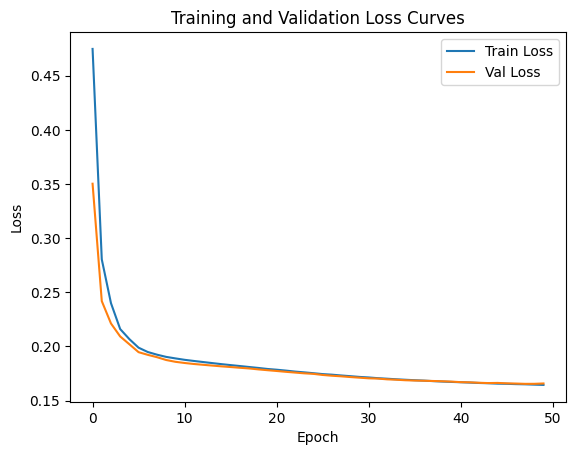

In [12]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

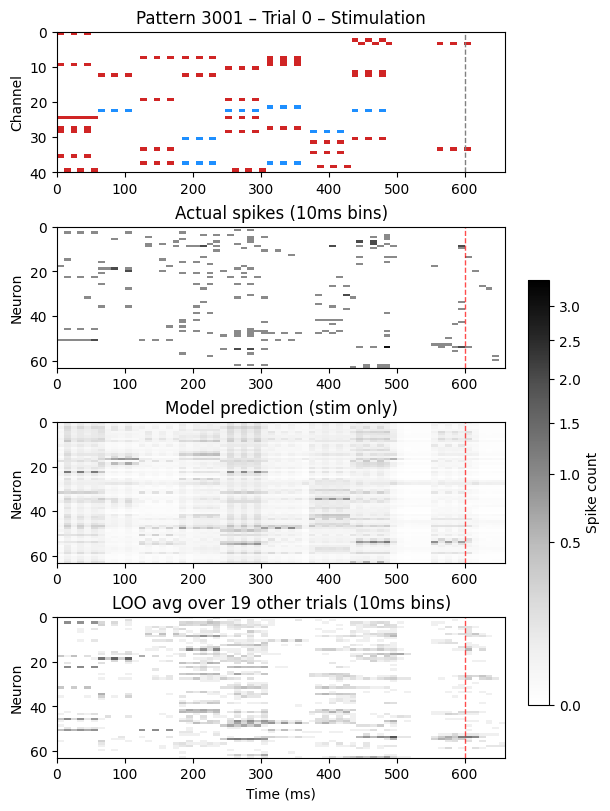

In [13]:
# ============================================================
# Visualize one trained CNN test example (oracle pattern), reusing
# patterns_5k/viz.py:plot_single_oracle_trial.
#
# Panels: stim polarity, actual spikes, model prediction, LOO trial average.
# ============================================================
import numpy as np
import torch
from viz import plot_single_oracle_trial

# Build the cfg + raw_data dicts the viz function expects.
cfg = dict(
    input_bin_size_ms  = CFG['INPUT_BIN_MS'],
    output_bin_size_ms = CFG['OUTPUT_BIN_MS'],
    n_input_bins       = CFG['N_INPUT_BINS'],
    n_output_bins      = CFG['N_OUTPUT_BINS'],
    max_time_ms        = CFG['MAX_TIME_MS'],
    output_offset      = 0,
    history            = 0,
    init_state         = False,
    encoding_mode      = CFG['ENCODING_MODE'],
)
raw_data = dict(
    pattern_df         = pattern_df,
    spike_responses    = spike_responses,
    pattern_polarities = pattern_polarities,
)
model_tuple = (model, base_criterion, device)

# Pick the first oracle pattern with at least 2 trials so LOO is meaningful.
unique_oracle = pattern_df[pattern_df['is_oracle']][['pattern_name', 'pattern_timing_index']].drop_duplicates()
counts = unique_oracle.groupby('pattern_name').size()
PATTERN_TO_SHOW = counts[counts >= 2].index[0] if (counts >= 2).any() else counts.index[0]
TRIAL_IDX = 0

fig = plot_single_oracle_trial(
    pattern_name=PATTERN_TO_SHOW,
    trial_idx=TRIAL_IDX,
    model_tuple=model_tuple,
    cfg=cfg,
    raw_data=raw_data,
    test_loader=test_loader,
    coarse_factor=1,
)

from IPython.display import display
fig.axes[2].set_title(f'Model prediction (stim only)')
display(fig)


### Stim creator

In [14]:
import heapq
import numpy as np
import torch


class StimCreator():
    """Greedy stim builder. Each 60 ms step (= 6 bins of 10 ms) can hold up to
    `budget_per_step` simultaneously-active channels; for each slot we try every
    (channel, encoding) candidate and keep the one whose model prediction has the
    smallest L2 distance to `target_spikes`.

    Hardware constraint enforced during the search: channels are partitioned
    into `n_shanks` equal-sized shanks by sorted channel ID, and at most
    `max_per_shank` channels per shank may fire SIMULTANEOUSLY (same bin within
    a step). Two channels with non-overlapping delay_mode bin-sets (e.g.
    dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5}) don't conflict.

    Encoding -> (offsets within the 6-bin step, amplitude) follows
    encode_pattern_nominal_current_10ms in patterns_5k/utils.py:
        delay_mode  0 -> bins {0,2,4}, +3
        delay_mode -1 -> bins {0,2,4}, -3
        delay_mode  1 -> bins {1,3,5}, +3
        delay_mode  2 -> bins {0..5},  +3
    """

    BINS_PER_STEP = 6  # 60 ms / 10 ms

    _ENCODING_TABLE = {
         0: ([0, 2, 4],            3), # 
        -1: ([0, 2, 4],           -3),
         1: ([1, 3, 5],           3),
         2: ([0, 1, 2, 3, 4, 5],   3),
    }

    def __init__(self, model, device, channel_to_index, n_bins,
                 n_shanks=4, max_per_shank=4, proj=None):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.channel_to_index = channel_to_index
        self.n_stim_channels = len(channel_to_index)
        self.n_bins = n_bins  # total 10 ms bins in the stim window

        # Shank partition: equal-sized chunks of sorted channel IDs.
        # Map ch_index (the row in the stim array) -> shank id.
        sorted_chs = sorted(channel_to_index.keys())
        if len(sorted_chs) % n_shanks != 0:
            raise ValueError(f"cannot split {len(sorted_chs)} channels into "
                             f"{n_shanks} equal shanks")
        shank_size = len(sorted_chs) // n_shanks
        ch_to_shank_by_id = {ch: i // shank_size
                             for i, ch in enumerate(sorted_chs)}
        # channel_to_index maps channel-id -> row in stim array; invert.
        self._idx_to_shank = np.empty(self.n_stim_channels, dtype=np.int64)
        for ch_id, idx in channel_to_index.items():
            self._idx_to_shank[idx] = ch_to_shank_by_id[ch_id]
        self.n_shanks = n_shanks
        self.max_per_shank = max_per_shank

        # Precompute bin-set per encoding.
        self._enc_bins = {enc: tuple(offsets)
                          for enc, (offsets, _amp) in self._ENCODING_TABLE.items()}
        
        # Projection for distance calculation: if provided, distance is measured in the projected space.
        if proj is not None:
            self.proj = proj
        else:
            self.proj = np.eye(n_neurons, dtype=np.float32)

    def stim_sequence_from_encoding(self, encoding):
        """Return a length-6 vector for one 60 ms step at 10 ms resolution."""
        seq = np.zeros(self.BINS_PER_STEP, dtype=np.float32)
        if encoding in self._ENCODING_TABLE:
            offsets, amp = self._ENCODING_TABLE[encoding]
            for o in offsets:
                seq[o] = amp
        return seq

    def _predict(self, stim, n_bins_truncate=None):
        """stim: (n_stim_channels, n_bins) -> (n_neurons, n_bins) numpy."""
        x = torch.from_numpy(stim).unsqueeze(0).to(self.device).float()
        with torch.no_grad():
            pred = self.model(x)
        if n_bins_truncate is not None:
            pred = pred[:, :, :n_bins_truncate]
        return torch.exp(pred).cpu().numpy()[0]

    def create_stim(self, target_spikes, budget_per_step=2,
                    encodings=(-1, 0, 1, 2), channels=None,
                    require_improvement=True, verbose=False):
        """Greedily build a stim driving the model toward `target_spikes`.

        Args:
            target_spikes: (n_neurons, n_bins) target.
            budget_per_step: max channels stimulated per 60 ms step.
            encodings: encoding labels to consider per slot.
            channels: stim-channel indices to consider (default: all).
            require_improvement: if True, stop filling a step's budget once no
                candidate strictly reduces distance.

        Returns:
            created_stim: (n_stim_channels, n_bins) float32.
            final_dist:   final L2 distance of model prediction to target.
        """
        if channels is None:
            channels = list(range(self.n_stim_channels))
        else:
            channels = list(channels)

        n_steps = self.n_bins // self.BINS_PER_STEP
        created_stim = np.zeros((self.n_stim_channels, self.n_bins), dtype=np.float32)
        used_channels_per_step = [set() for _ in range(n_steps)]
        # Per-step (shank, bin)-occupancy: shank_bin_count[step][shank, bin].
        shank_bin_count = [
            np.zeros((self.n_shanks, self.BINS_PER_STEP), dtype=np.int32)
            for _ in range(n_steps)
        ]
        curr_dist = np.linalg.norm(self._predict(created_stim, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
        if verbose:
            print(f"baseline dist: {curr_dist:.4f}")

        # Precompute encoding sequences.
        enc_seqs = [(e, self.stim_sequence_from_encoding(e)) for e in encodings]

        for step in range(n_steps):
            t0 = step * self.BINS_PER_STEP
            t1 = t0 + self.BINS_PER_STEP
            occ = shank_bin_count[step]

            for _ in range(budget_per_step):
                # Initialize best to the "add nothing this slot" option: the
                # distance of the stim as it currently stands (ch/enc/seq=None).
                # A real candidate is only chosen if it beats doing nothing.
                best = (curr_dist, None, None, None)  # (dist, ch, enc, seq)
                for ch in channels:
                    if ch in used_channels_per_step[step]:
                        continue
                    shank = self._idx_to_shank[ch]
                    for enc, seq in enc_seqs:
                        # Reject any candidate that would push a (shank, bin)
                        # cell above max_per_shank for this step.
                        bins_used = self._enc_bins[enc]
                        if any(occ[shank, b] + 1 > self.max_per_shank
                               for b in bins_used):
                            continue
                        cand = created_stim.copy()
                        cand[ch, t0:t1] = seq
                        d = np.linalg.norm(self._predict(cand, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
                        if d < best[0]: # greedy: must beat current best (incl. do-nothing)
                            best = (d, ch, enc, seq)

                # If the best option is to add nothing (no candidate beat the
                # do-nothing distance), stop filling this step's budget.
                if best[1] is None:
                    break
                if require_improvement and best[0] >= curr_dist:
                    break

                d, ch, enc, seq = best
                created_stim[ch, t0:t1] = seq
                used_channels_per_step[step].add(ch)
                # Commit the bin occupancy for the chosen channel/encoding.
                shank = self._idx_to_shank[ch]
                for b in self._enc_bins[enc]:
                    occ[shank, b] += 1
                curr_dist = d
                if verbose:
                    print(f"  step {step}: ch={ch}, enc={enc:>2}, dist={d:.4f}")

        return created_stim, curr_dist


In [43]:
VIS_ORIENT_TIME = 600  # ms window for visual orientation decoding (from above analysis)
BUDGET = 10

if VIS_ORIENT_TIME > STIM_MS: 
    fac = VIS_ORIENT_TIME / STIM_MS
else:
    fac = 1
targets = sum_responses[:, :, :VIS_ORIENT_TIME // 10].sum(axis=2) * fac  # (n_orientations, n_neurons, n_bins) -> (n_orientations, n_neurons, 12) bc 10 ms bins scaled
est_stims = []
distances = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]  # (n_neurons,)
    stim_creator = StimCreator(model, device, channel_to_index, n_bins=VIS_ORIENT_TIME // 10, proj=proj)
    created_stim, final_dist = stim_creator.create_stim(
        target_spikes=target_spikes,
        budget_per_step=BUDGET,
        encodings=[-1, 0, 1, 2],
        channels=None,
        require_improvement=True,
        verbose=True,
    )
    est_stims.append(created_stim)
    distances.append(final_dist)
    print(f"Orientation {orientation}°: final dist={final_dist:.4f}")


baseline dist: 45.9920
  step 0: ch=30, enc= 2, dist=38.7459
  step 0: ch=26, enc= 2, dist=35.4374
  step 0: ch=31, enc=-1, dist=32.6090
  step 0: ch=13, enc=-1, dist=31.9003
  step 0: ch=28, enc= 0, dist=31.3284
  step 0: ch=37, enc=-1, dist=31.0295
  step 0: ch=25, enc= 0, dist=30.2819
  step 1: ch=30, enc= 2, dist=23.5564
  step 1: ch=26, enc= 2, dist=20.8181
  step 1: ch=31, enc=-1, dist=18.1345
  step 1: ch=13, enc=-1, dist=17.5772
  step 1: ch=25, enc= 0, dist=16.8698
  step 2: ch=30, enc= 2, dist=9.8881
  step 2: ch=26, enc= 2, dist=7.2913
  step 2: ch=31, enc=-1, dist=4.9185
  step 2: ch=13, enc=-1, dist=4.6544
  step 2: ch=28, enc= 0, dist=4.0268
  step 2: ch=22, enc=-1, dist=3.7910
  step 2: ch=25, enc= 0, dist=3.4225
  step 3: ch=22, enc=-1, dist=2.1824
  step 3: ch=39, enc= 1, dist=2.1382
  step 3: ch=36, enc= 1, dist=2.0996
  step 3: ch=10, enc= 2, dist=2.0965
  step 3: ch=33, enc= 0, dist=2.0404
  step 3: ch=37, enc= 0, dist=1.9584
  step 3: ch=35, enc= 0, dist=1.9203
  s

(63, 60)


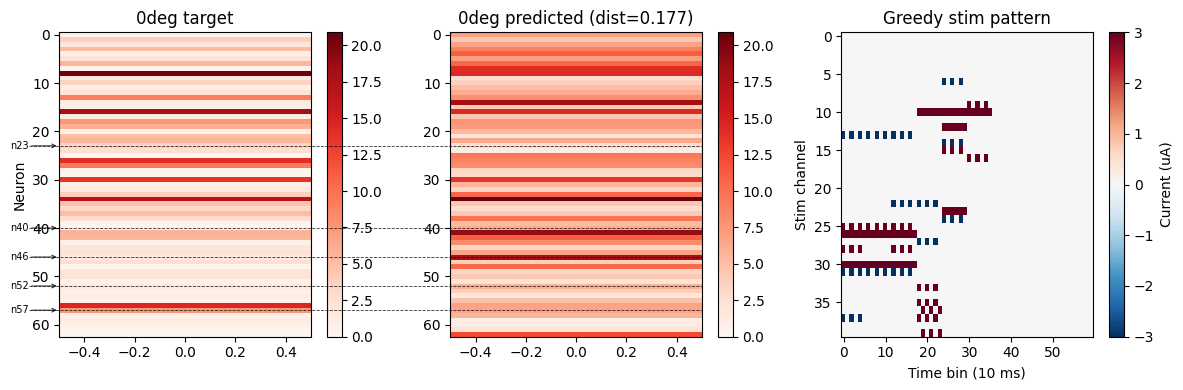

(63, 60)


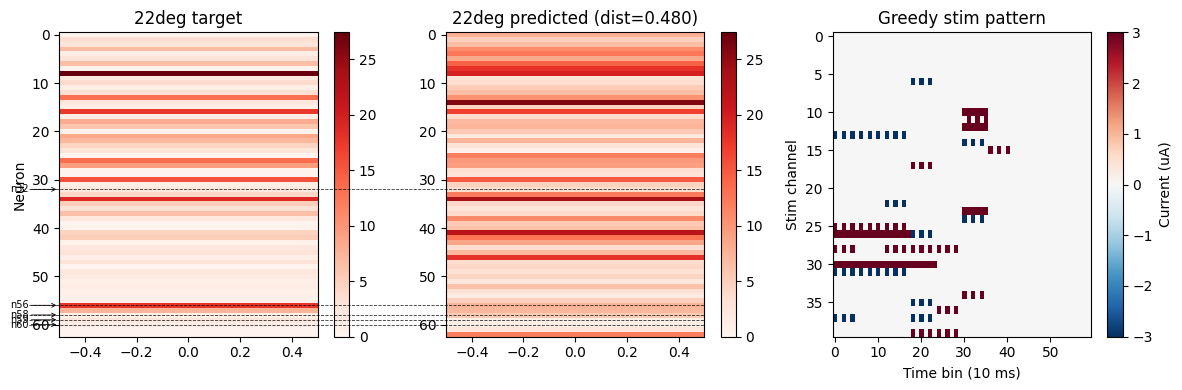

(63, 60)


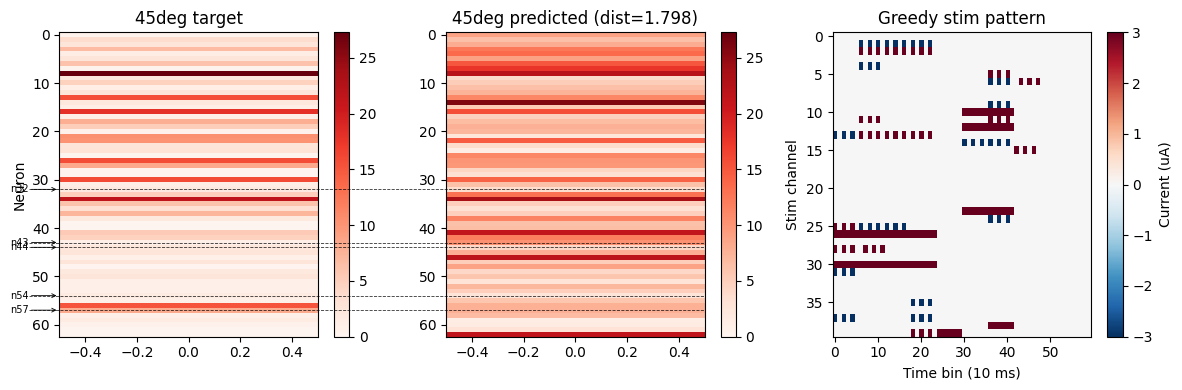

(63, 60)


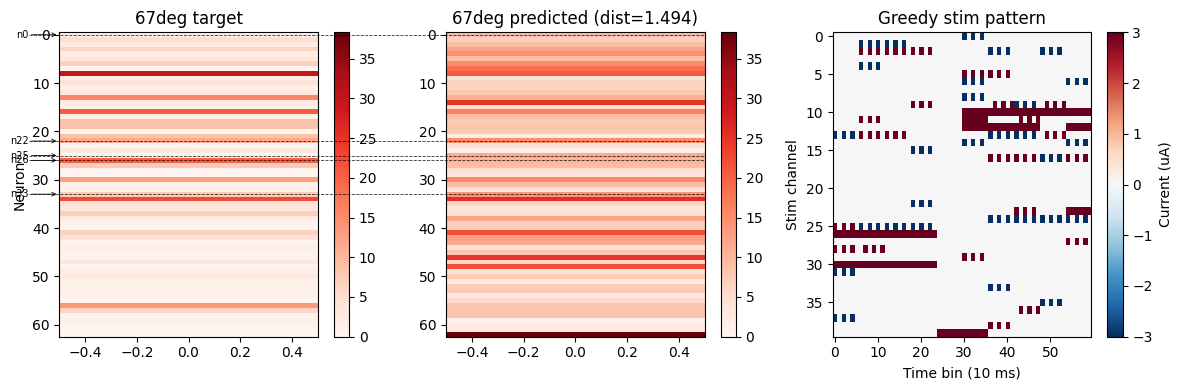

(63, 60)


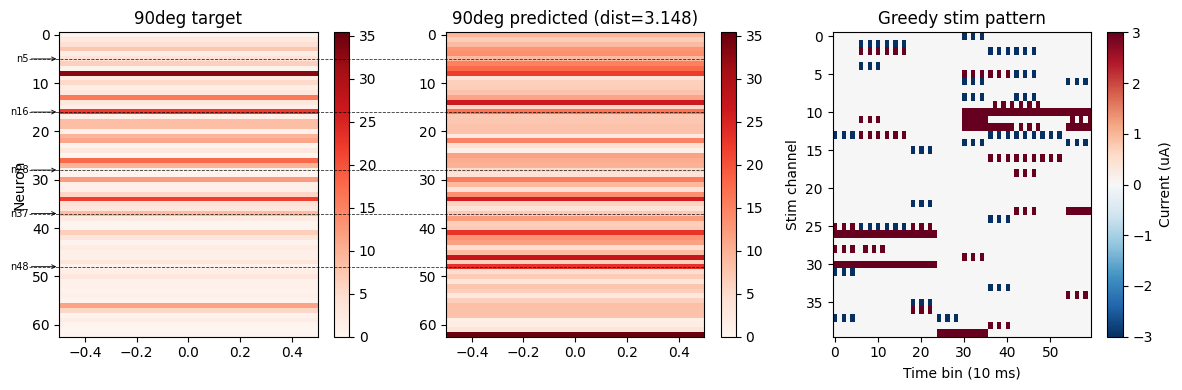

(63, 60)


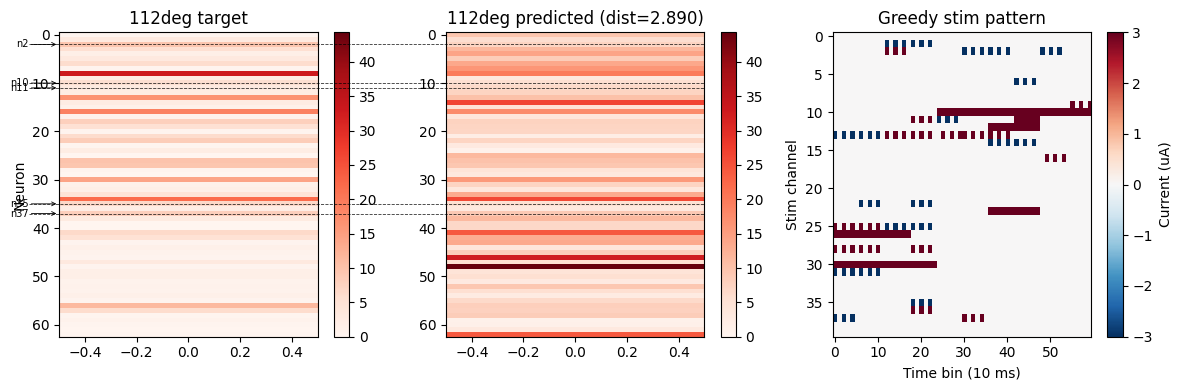

(63, 60)


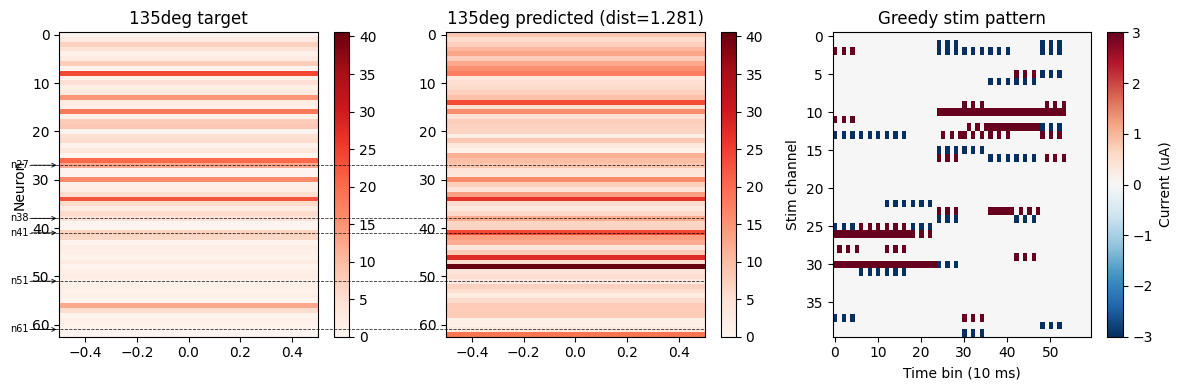

(63, 60)


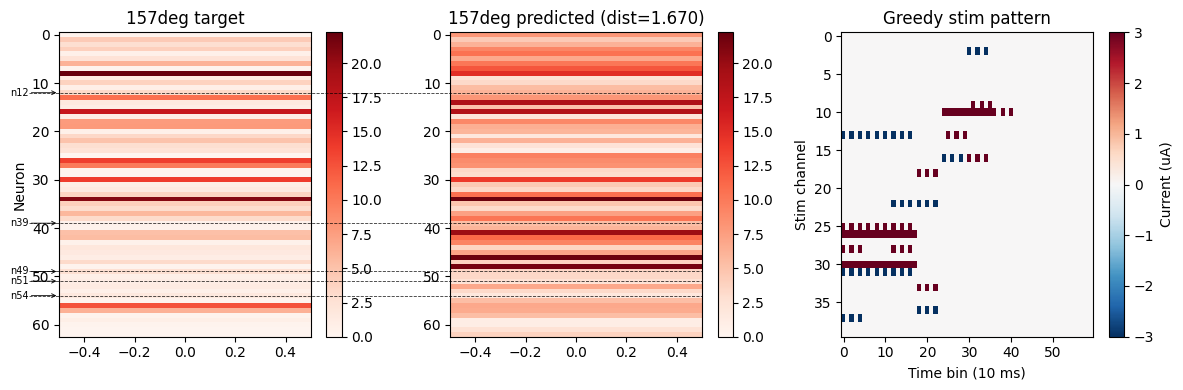

(63, 60)


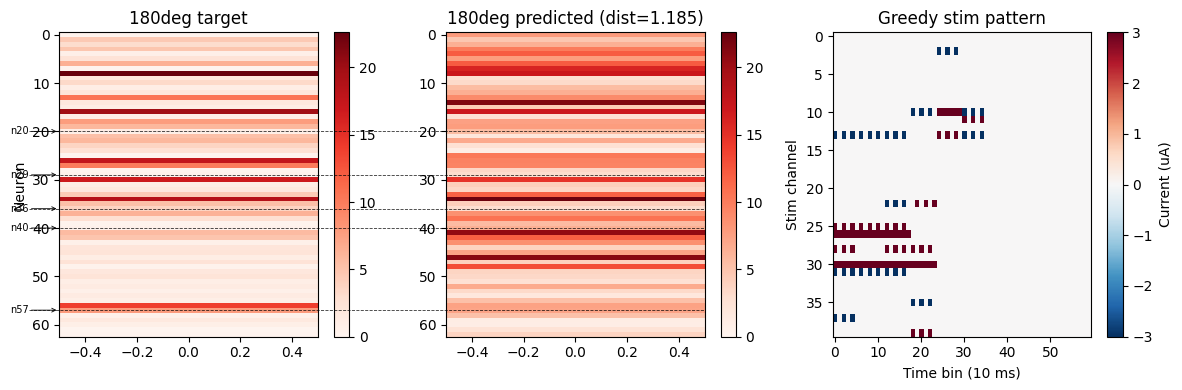

(63, 60)


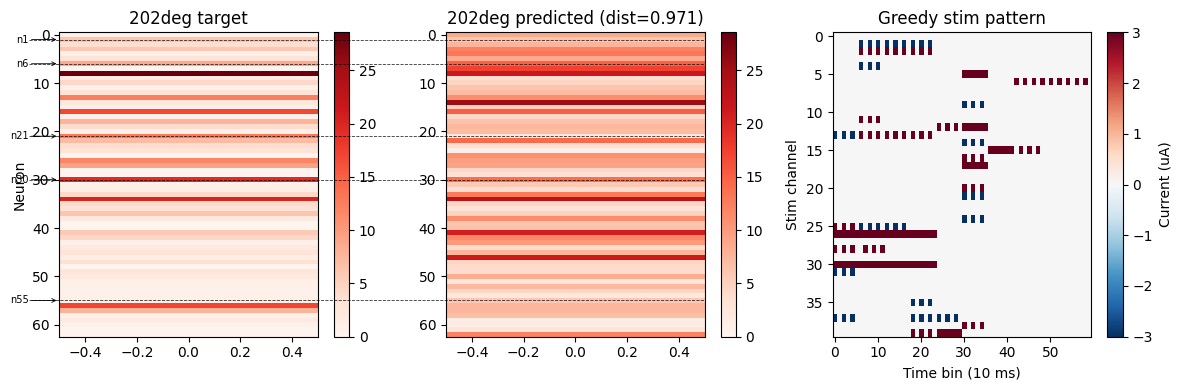

(63, 60)


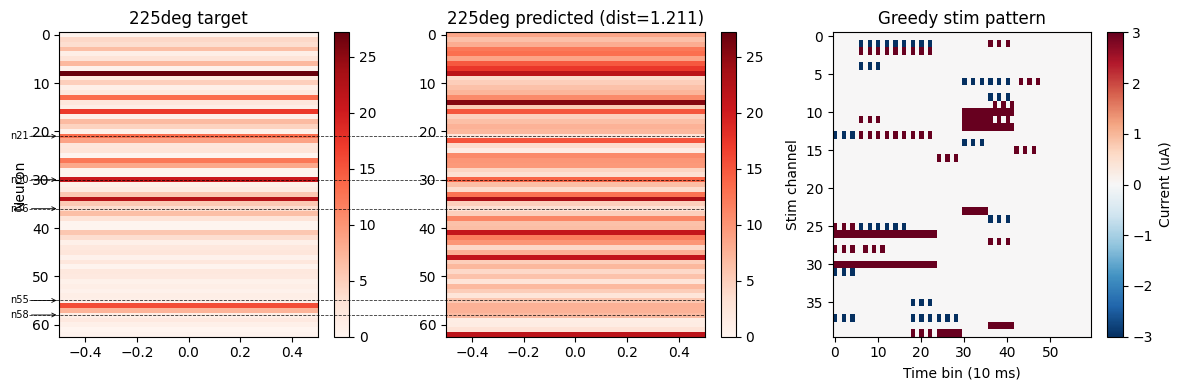

(63, 60)


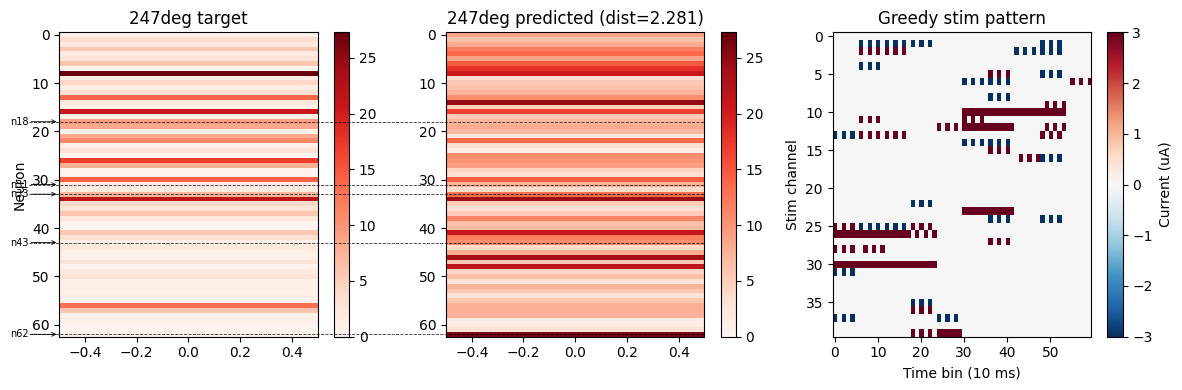

(63, 60)


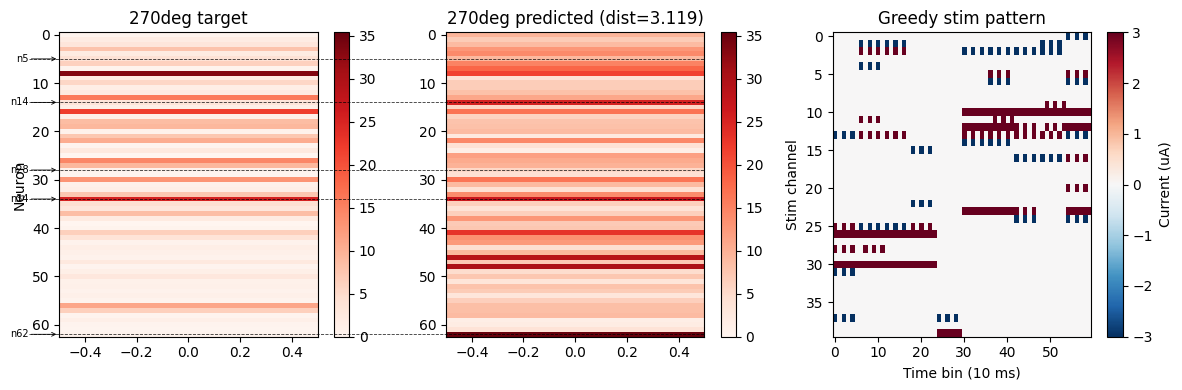

(63, 60)


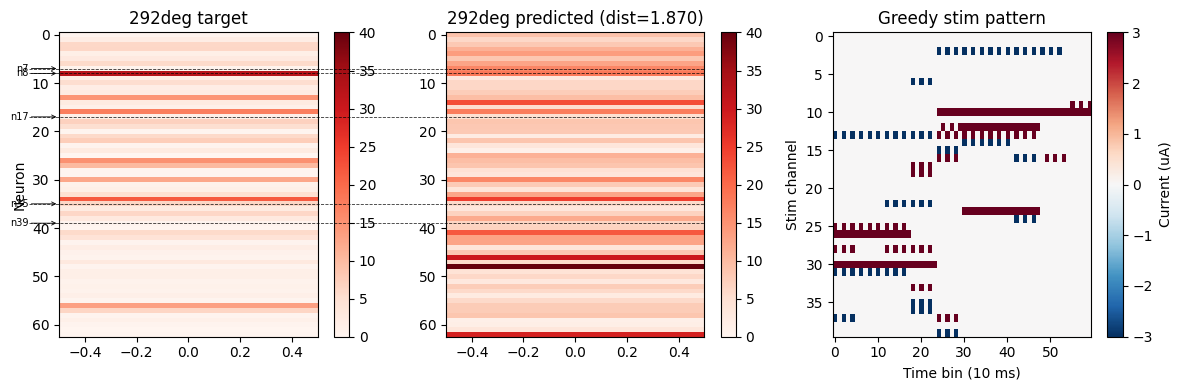

(63, 60)


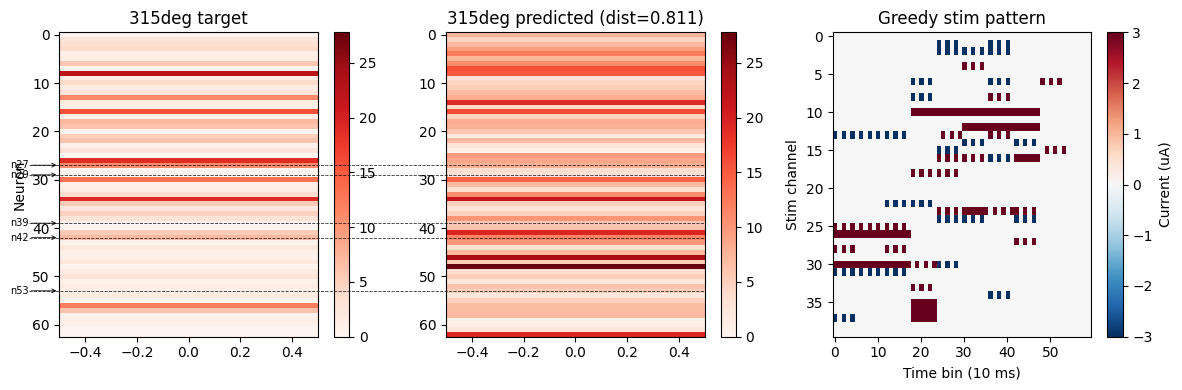

(63, 60)


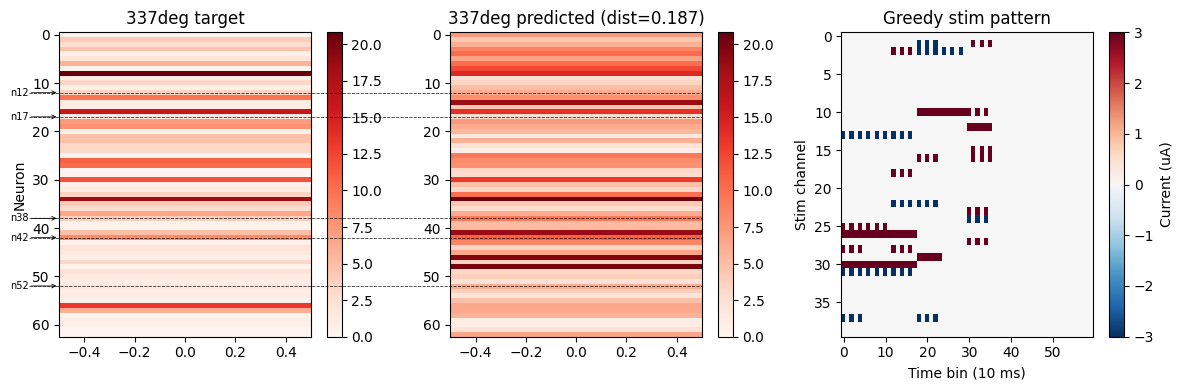

In [44]:
# Plot per orientation (3 horizontal imshow panels): target, predicted, stim.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import offset_copy

# Selectivity: per-(orient, neuron) z-score across orientations.
mu_n        = orient_total.mean(axis=0)
sigma_n     = orient_total.std(axis=0)
selectivity = (orient_total - mu_n) / (sigma_n + 1e-9)        # (n_orient, n_neurons)

ARROW_TEXT_OFFSET_PTS = -22  # matches xytext below

for o_idx, deg in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]                  # (n_neurons,)
    created_stim  = est_stims[o_idx]                # (n_stim_channels, n_bins)

    x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred = torch.exp(model(x)).cpu().numpy()[0]            # (n_neurons, n_bins)
    print (pred.shape)
    pred_counts = pred[:, :VIS_ORIENT_TIME // 10].sum(axis=1)                  # (n_neurons,) # truncated to same window as target

    f, ax = plt.subplots(1, 3, figsize=(12, 4))
    vmax = max(np.abs(target_spikes).max(), np.abs(pred_counts).max(), 1e-6)

    ax[0].imshow(target_spikes.reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='Reds', vmin=0, vmax=vmax)
    ax[0].set_title(f'{int(deg)}deg target')
    ax[0].set_ylabel('Neuron')
    plt.colorbar(ax[0].images[0], ax=ax[0])

    # Arrow ticks for the top-5 most positively selective neurons for this
    # orientation.
    top5 = np.argsort(selectivity[o_idx])[::-1][:5]
    for nidx in top5:
        ax[0].annotate(
            f'n{int(nidx)}',
            xy=(0, nidx), xycoords=('axes fraction', 'data'),
            xytext=(ARROW_TEXT_OFFSET_PTS, 0), textcoords='offset points',
            ha='right', va='center', fontsize=7, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.6,
                            shrinkA=0, shrinkB=2),
            annotation_clip=False,
        )

    ax[1].imshow(pred_counts.reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='Reds', vmin=0, vmax=vmax)
    ax[1].set_title(f'{int(deg)}deg predicted (dist={distances[o_idx]:.3f})')
    plt.colorbar(ax[1].images[0], ax=ax[1])

    amp_max = max(np.abs(created_stim).max(), 1)
    ax[2].imshow(created_stim, aspect='auto', interpolation='nearest',
                 cmap='RdBu_r', vmin=-amp_max, vmax=amp_max)
    ax[2].set_title('Greedy stim pattern')
    ax[2].set_xlabel('Time bin (10 ms)')
    ax[2].set_ylabel('Stim channel')
    plt.colorbar(ax[2].images[0], ax=ax[2], label='Current (uA)')

    plt.tight_layout()

    # Dashed lines from each arrow's tail (label position) across the first two
    # subplots, ending at the right edge of ax[1]'s axes box.
    f.canvas.draw()
    inv = f.transFigure.inverted()
    base = ax[0].get_yaxis_transform()  # ('axes fraction', 'data')
    tail_tf = offset_copy(base, fig=f, x=ARROW_TEXT_OFFSET_PTS, y=0, units='points')
    right_tf = ax[1].get_yaxis_transform()  # ('axes fraction', 'data') for ax[1]
    for nidx in top5:
        p_left  = inv.transform(tail_tf.transform((0, nidx)))
        p_right = inv.transform(right_tf.transform((1, nidx)))
        line = Line2D([p_left[0], p_right[0]], [p_left[1], p_right[1]],
                      transform=f.transFigure, color='black',
                      linestyle='--', linewidth=0.6, alpha=0.8, zorder=10)
        f.add_artist(line)
    plt.savefig(f'results/greedy_stim_budget{BUDGET}_{int(deg)}deg_{mode}".png', dpi=300)
    plt.show()


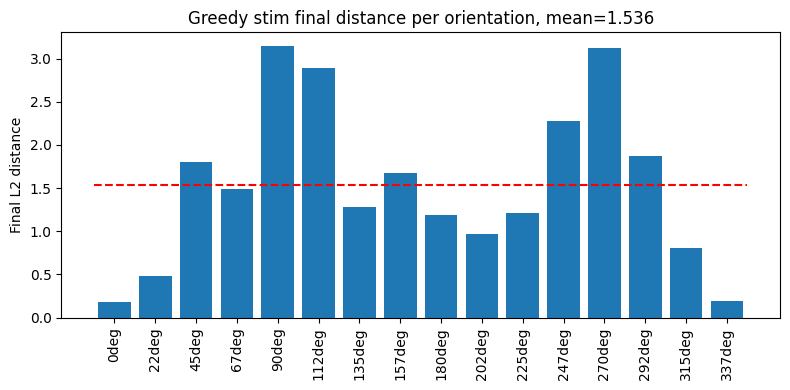

In [45]:
# Final L2 distance per orientation.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(visual_orientation_degs)), distances, color='C0')
ax.hlines(np.mean(distances), xmin=-0.5, xmax=len(visual_orientation_degs)-0.5, colors='red', linestyles='dashed', label='Mean')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_ylabel('Final L2 distance')
ax.set_title('Greedy stim final distance per orientation, mean={:.3f}'.format(np.mean(distances)))
plt.tight_layout()
plt.savefig(f'results/greedy_stim_budget{BUDGET}_exp_final_distances_{mode}.png', dpi=300)
plt.show()


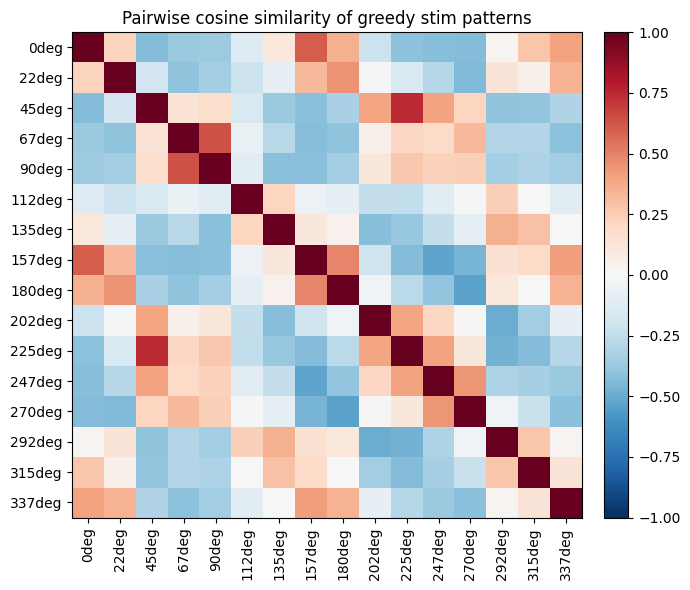

unique stim patterns (exact): 16 / 16
exact-match pairs: 0
mean off-diagonal cosine sim: -0.065


In [46]:
# Pairwise cosine similarity of greedy stim patterns across orientations.
from sklearn.preprocessing import normalize
import numpy as np 
stim_flat = np.stack([s.flatten() for s in est_stims], axis=0)  # (n_orient, n_ch * n_bins)
stim_flat = stim_flat - stim_flat.mean(axis=0, keepdims=True)  # zero-center for cosine similarity
stim_normed = normalize(stim_flat, norm='l2')
sim_stim = stim_normed @ stim_normed.T  # (n_orient, n_orient)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_stim, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
ax.set_title('Pairwise cosine similarity of greedy stim patterns')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f'results/greedy_stim_budget{BUDGET}_{mode}_similarity.png', dpi=300)
plt.show()

# Quick uniqueness summary.
n_orient = len(est_stims)
exact_matches = sum(
    1 for i in range(n_orient) for j in range(i + 1, n_orient)
    if np.array_equal(est_stims[i], est_stims[j])
)

unique_count = len({s.tobytes() for s in est_stims})
print(f'unique stim patterns (exact): {unique_count} / {n_orient}')
print(f'exact-match pairs: {exact_matches}')
print(f'mean off-diagonal cosine sim: {sim_stim[np.triu_indices(n_orient, k=1)].mean():.3f}')


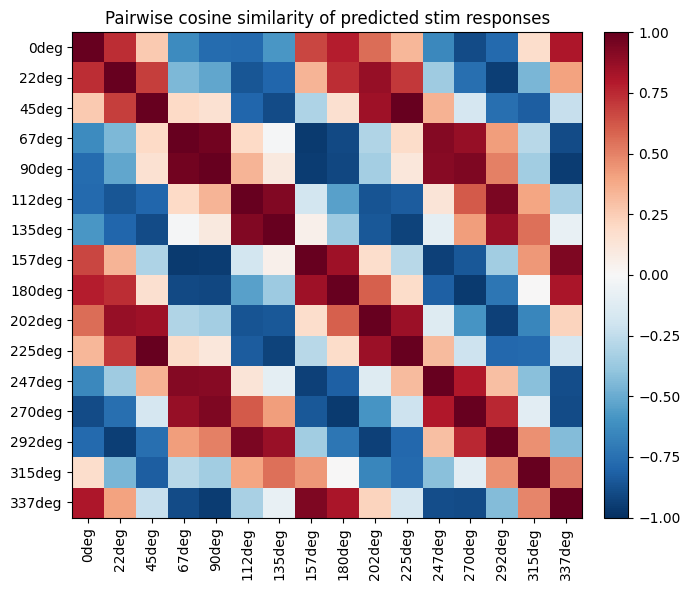

In [47]:
# cosine similarity of predicted stim response vectors 
pred_responses = []
for created_stim in est_stims:
    x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred = torch.exp(model(x)).cpu().numpy()[0]            # (n_neurons, n_bins)
    pred_counts = pred[:, :VIS_ORIENT_TIME // 10].sum(axis=1)                  # (n_neurons,)
    pred_responses.append(pred_counts)
pred_responses = np.stack(pred_responses, axis=0)   # (n_orient, n_neurons)
pred_responses_normed = normalize(pred_responses - np.mean(pred_responses, axis=0), norm='l2')
sim_pred_resp = pred_responses_normed @ pred_responses_normed.T  # (n_orient, n_orient) 
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_pred_resp, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
ax.set_title('Pairwise cosine similarity of predicted stim responses')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04        )
plt.tight_layout()
plt.savefig(f'results/greedy_stim_budget{BUDGET}_{mode}_pred_response_similarity.png', dpi=300)
plt.show()

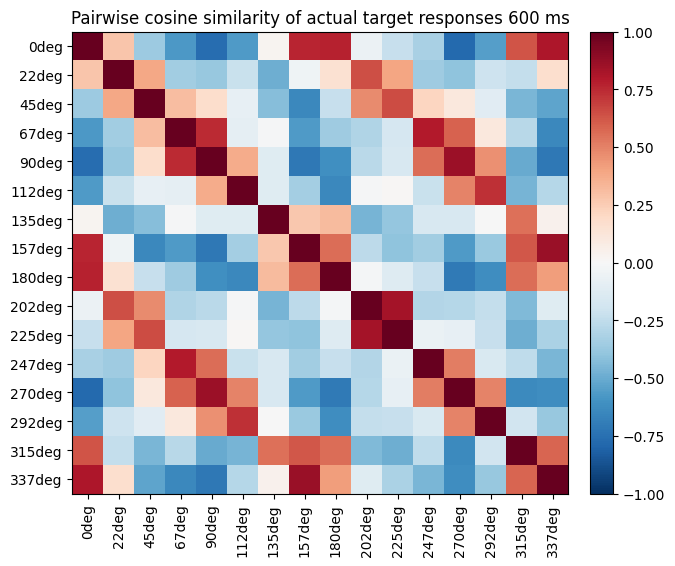

In [48]:
# pairwise cosine similarity of target response vectors (for reference)
targets_normed = normalize(targets - np.mean(targets, axis=0), norm='l2')
sim_target_resp = targets_normed @ targets_normed.T  # (n_orient, n_orient) 
fig, ax = plt.subplots(figsize=(7, 6))          
im = ax.imshow(sim_target_resp, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04        )
ax.set_title(f'Pairwise cosine similarity of actual target responses {VIS_ORIENT_TIME} ms')     
plt.savefig(f'results/target_response_similarity.png', dpi=300)     

In [49]:
# Project everything (observed averages, per-trial dots, CNN predictions) into a
# shared (CIS, PC1, PC2) space built from the SAME VIS_ORIENT_TIME window used
# to define the targets, so all three live on a common scale.
import plotly.graph_objects as go
from sklearn.decomposition import PCA

if mode == "pca": 
    # Rebuild the projection from `targets` (== sum_responses windowed to VIS_ORIENT_TIME).
    X_win        = targets                                      # (n_orient, n_neurons)
    mean_vec_win = X_win.mean(axis=0, keepdims=True)
    pca_win      = PCA(n_components=2).fit(X_win)
    proj_win, _  = np.linalg.qr(np.array([
        mean_vec_win[0],
        pca_win.components_[0],
        pca_win.components_[1],
    ]).T)                                                       # (n_neurons, 3)
    coords_win   = X_win @ proj_win                             # (n_orient, 3)
elif mode == "lda":
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    lda_win = LinearDiscriminantAnalysis(n_components=2).fit(trial_raw_counts, lda_labels)
    proj_win, _ = np.linalg.qr(np.column_stack([
        lda_win.means_.mean(axis=0),  # overall mean
        lda_win.scalings_[:, 0],     # LD1
        lda_win.scalings_[:, 1],     # LD2
    ]))                               # (n_neurons, 3)
    coords_win = targets @ proj_win   # (n_orient, 3)
else:
    raise ValueError(f"invalid mode: {mode}")

# CNN predictions under greedy stims (already over the VIS_ORIENT_TIME window).
greedy_pred_full = np.zeros((len(visual_orientation_degs), n_neurons), dtype=np.float32)
for o_idx in range(len(visual_orientation_degs)):
    x = torch.from_numpy(est_stims[o_idx]).unsqueeze(0).to(device).float()
    with torch.no_grad():
        rate = torch.exp(model(x))                          # (1, n_neurons, n_bins)
    greedy_pred_full[o_idx] = rate[0, :, :VIS_ORIENT_TIME // 10].sum(dim=1).cpu().numpy()
greedy_coords_win = greedy_pred_full @ proj_win

# Per-trial dots over the same VIS_ORIENT_TIME window.
vis_window_samples = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj_win)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    name='Per-trial', hoverinfo='skip',
))
fig.add_trace(go.Scatter3d(
    x=coords_win[:, 0], y=coords_win[:, 1], z=coords_win[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(title='Orientation (deg)')),
    text=[f'{int(o)}deg' for o in visual_orientation_degs],
    textposition='top center',
    name='Observed orientation avg',
))
fig.add_trace(go.Scatter3d(
    x=greedy_coords_win[:, 0], y=greedy_coords_win[:, 1], z=greedy_coords_win[:, 2],
    mode='markers',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond', line=dict(color='white', width=1)),
    name='Greedy stim CNN prediction',
))
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter3d(
        x=[coords_win[o, 0], greedy_coords_win[o, 0]],
        y=[coords_win[o, 1], greedy_coords_win[o, 1]],
        z=[coords_win[o, 2], greedy_coords_win[o, 2]],
        mode='lines', line=dict(color='gray', width=2, dash='dot'),
        showlegend=(o == 0), name='match link', hoverinfo='skip',
    ))

fig.update_layout(
    title=f'Observed vs CNN-predicted responses (all over {VIS_ORIENT_TIME} ms window)',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=850, height=700,
)
fig.write_image(
    f'results/greedy_stim_budget{BUDGET}_{mode}_pred_vs_target_3d.png', 
    scale=3
)

fig.show()


In [50]:
# Project observed averages, per-trial dots, and CNN predictions into PC1/PC2,
# computed from the same VIS_ORIENT_TIME window used to define the targets.
import os
import plotly.graph_objects as go
from sklearn.decomposition import PCA

X_win  = targets                                # (n_orient, n_neurons)
pca_win = PCA(n_components=2).fit(X_win)
proj_win = pca_win.components_.T                # (n_neurons, 2)
coords_win = X_win @ proj_win                   # (n_orient, 2)

# CNN predictions under greedy stims (already over the VIS_ORIENT_TIME window).
greedy_pred_full = np.zeros((len(visual_orientation_degs), n_neurons), dtype=np.float32)
for o_idx in range(len(visual_orientation_degs)):
    x = torch.from_numpy(est_stims[o_idx]).unsqueeze(0).to(device).float()
    with torch.no_grad():
        rate = torch.exp(model(x))              # (1, n_neurons, n_bins)
    greedy_pred_full[o_idx] = rate[0, :, :VIS_ORIENT_TIME // 10].sum(dim=1).cpu().numpy()
greedy_coords_win = greedy_pred_full @ proj_win

# Per-trial dots over the same VIS_ORIENT_TIME window.
vis_window_samples = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj_win)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial cloud
fig.add_trace(go.Scatter(
    x=trial_coords[:, 0], y=trial_coords[:, 1],
    mode='markers',
    marker=dict(size=5, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    hoverinfo='skip', showlegend=False,
))

# Match links between observed and predicted
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter(
        x=[coords_win[o, 0], greedy_coords_win[o, 0]],
        y=[coords_win[o, 1], greedy_coords_win[o, 1]],
        mode='lines', line=dict(color='gray', width=1, dash='dot'),
        hoverinfo='skip', showlegend=False,
    ))

# Observed orientation averages (circles)
fig.add_trace(go.Scatter(
    x=coords_win[:, 0], y=coords_win[:, 1],
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                )),
    showlegend=False,
))

# Greedy CNN predictions (diamonds)
fig.add_trace(go.Scatter(
    x=greedy_coords_win[:, 0], y=greedy_coords_win[:, 1],
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond', line=dict(color='white', width=1)),
    showlegend=False,
))

fig.update_layout(
    title=f'Observed vs CNN-predicted responses ({VIS_ORIENT_TIME} ms window)',
    xaxis_title='PC1', yaxis_title='PC2',
    width=850, height=700,
)

os.makedirs('results', exist_ok=True)
fig.write_html(f'results/vis_response_pc1_pc2_recon_{BUDGET}.html', include_plotlyjs='cdn')
try:
    fig.write_image(f'results/vis_response_pc1_pc2_recon_{BUDGET}.svg', width=850, height=700, scale=2)
    fig.write_image(f'results/vis_response_pc1_pc2_recon_{BUDGET}.pdf', width=850, height=700, scale=2)
except Exception as e:
    print(f'[image export skipped: {e}]')
    print('Open the HTML in a browser and File > Print > Save as PDF for vector output.')
fig.show()


In [51]:
# ============================================================
# Build pattern registrations directly from est_stims (16 unique patterns,
# 2 steps of 60 ms each). For each step, decode the 6-bin slice on each
# channel into a (channel, delay_mode) entry -- no redistribution.
#
# Hardware constraint: channels are partitioned into 4 equal-sized shanks
# by sorted channel ID, and at most MAX_PER_SHANK channels per shank may
# fire SIMULTANEOUSLY (same bin within a step). Channels with non-overlapping
# delay_mode bin-sets (e.g. dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5})
# don't conflict and may share a shank. Offending channels are flagged and
# dropped to make every (shank, bin) <= MAX_PER_SHANK.
# ============================================================
import pickle
import copy
import itertools
from collections import Counter

K_TRIALS = 1
SHUFFLE_SEED = 0
BINS_PER_STEP = StimCreator.BINS_PER_STEP
STEP_MS = 60
n_bins = est_stims[0].shape[1]
n_steps = n_bins // BINS_PER_STEP
index_to_channel = {idx: ch for ch, idx in channel_to_index.items()}

# ---- Shank partition: 4 equal-sized shanks by sorted channel ID ----
MAX_PER_SHANK = 4
N_SHANKS = 4


sorted_channels = sorted(channel_to_index.keys())
assert len(sorted_channels) % N_SHANKS == 0, (
    f'cannot split {len(sorted_channels)} channels into {N_SHANKS} equal shanks')
shank_size = len(sorted_channels) // N_SHANKS
channel_to_shank = {ch: i // shank_size for i, ch in enumerate(sorted_channels)}
print(f'shanks: {N_SHANKS} x {shank_size} channels  '
      f'(max {MAX_PER_SHANK} simultaneous per shank per bin)')

def slice_to_delay_mode(slice6):
    if not np.any(slice6):
        return None
    for dm, (offsets, amp) in StimCreator._ENCODING_TABLE.items():
        target = np.zeros(BINS_PER_STEP, dtype=np.float32)
        for o in offsets:
            target[o] = amp
        if np.array_equal(slice6, target):
            return dm
    return None

# bin-set per delay_mode -- two channels collide only if these intersect.
DM_BINS = {dm: set(offsets) for dm, (offsets, _amp) in StimCreator._ENCODING_TABLE.items()}

def enforce_shank_limit(cds, ori_idx, step_idx):
    """At most MAX_PER_SHANK channels firing per (shank, bin).

    Walks channels in ascending order; drops a channel if adding it would
    push any (shank, bin) count above the limit. Flags every drop.
    """
    live = {}  # shank -> {bin_idx: count}
    kept, dropped_log = [], []
    for cd in cds:
        shank = channel_to_shank[cd['channel']]
        bins_used = DM_BINS[cd['delay_mode']]
        shank_counts = live.setdefault(shank, {})
        if any(shank_counts.get(b, 0) + 1 > MAX_PER_SHANK for b in bins_used):
            dropped_log.append((shank, cd['channel'], cd['delay_mode']))
            continue
        for b in bins_used:
            shank_counts[b] = shank_counts.get(b, 0) + 1
        kept.append(cd)
    if dropped_log:
        by_shank_drop = {}
        for shank, ch, dm in dropped_log:
            by_shank_drop.setdefault(shank, []).append((ch, dm))
        for shank, items in by_shank_drop.items():
            print(f'[shank-violation] orient {ori_idx} step {step_idx} '
                  f'shank {shank}: dropping {len(items)} channel(s) '
                  f'that exceed {MAX_PER_SHANK} simultaneous: '
                  f'{[(ch, dm) for ch, dm in items]}')
    return kept

# Build canonical step lists straight from each est_stims entry.
unique_patterns = []
for ori_idx, stim in enumerate(est_stims):
    steps_lists = []
    for s in range(n_steps):
        cds = []
        for ch in range(stim.shape[0]):
            sl = stim[ch, s * BINS_PER_STEP:(s + 1) * BINS_PER_STEP]
            dm = slice_to_delay_mode(sl)
            if dm is not None:
                cds.append({'channel': int(index_to_channel[ch]), 'delay_mode': int(dm)})
            elif np.any(sl):
                print(f'[warn] orient {ori_idx} ch {ch} step {s}: unrecognized slice {sl}')
        cds = enforce_shank_limit(cds, ori_idx, s)
        steps_lists.append(cds)
    unique_patterns.append({
        'ori_idx': int(ori_idx),
        'pattern_name': f'50{int(ori_idx)}',
        'steps_lists': steps_lists,
    })

# Expand to K_TRIALS each, shuffle to interleave.
rng = np.random.default_rng(SHUFFLE_SEED)
trial_slots = [(p['ori_idx'], p['pattern_name']) for p in unique_patterns for _ in range(K_TRIALS)]
order = rng.permutation(len(trial_slots))

generated_patterns = []
for new_pos, slot_idx in enumerate(order):
    ori_idx, pname = trial_slots[slot_idx]
    src = next(p for p in unique_patterns if p['ori_idx'] == ori_idx)
    steps = [
        {'index': step_idx, 'channel_delays': copy.deepcopy(cd), 'start_timestamp': 0}
        for step_idx, cd in enumerate(src['steps_lists'])
    ]
    generated_patterns.append({
        'pattern_name': pname,
        'pattern_lambda': 0.0,
        'pattern_flag_start_timestamp': 0,
        'pattern_timing_index': new_pos + 1,
        'steps': steps,
    })

# ---- Final per-bin shank-limit assertion (post-drop, must always pass) ----
for p in generated_patterns:
    for s in p['steps']:
        per_shank_bin = {}  # (shank, bin) -> count
        for cd in s['channel_delays']:
            shank = channel_to_shank[cd['channel']]
            for b in DM_BINS[cd['delay_mode']]:
                key = (shank, b)
                per_shank_bin[key] = per_shank_bin.get(key, 0) + 1
        for (shank, b), n in per_shank_bin.items():
            assert n <= MAX_PER_SHANK, (
                f'pattern {p["pattern_name"]} step {s["index"]} shank {shank} '
                f'bin {b}: {n} > {MAX_PER_SHANK} after drop -- bug in enforce_shank_limit')
print(f'[OK] all {len(generated_patterns)} trials respect <={MAX_PER_SHANK} simultaneous per shank per bin')

out_path = f'{datadir}/generated_pattern_registration_{BUDGET}budget_{VIS_ORIENT_TIME}ms_{mode}.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(generated_patterns, f)
print(f'Wrote {len(generated_patterns)} trials ({len(unique_patterns)} unique patterns x {K_TRIALS}) to {out_path}')

# ---- Schema validation against the reference file ----
with open(f'{datadir}/Combined_Pattern_Registrations.pkl', 'rb') as f:
    ref = pickle.load(f)
ref_keys = set(ref[0].keys()); gen_keys = set(generated_patterns[0].keys())
assert ref_keys == gen_keys, f'top-level keys differ: ref-only={ref_keys-gen_keys}, gen-only={gen_keys-ref_keys}'
ref_step_keys = set(ref[0]['steps'][0].keys()); gen_step_keys = set(generated_patterns[0]['steps'][0].keys())
assert ref_step_keys == gen_step_keys, 'step keys differ'
print('[OK] schema matches Combined_Pattern_Registrations.pkl')

# ---- Trial / timing-index sanity ----
timing_idxs = [p['pattern_timing_index'] for p in generated_patterns]
assert len(set(timing_idxs)) == len(timing_idxs)
assert sorted(timing_idxs) == list(range(1, len(generated_patterns) + 1))
name_counts = Counter(p['pattern_name'] for p in generated_patterns)
assert all(c == K_TRIALS for c in name_counts.values()), f'unequal trial counts: {name_counts}'
names_in_order = [p['pattern_name'] for p in generated_patterns]
max_run = max(len(list(g)) for _, g in itertools.groupby(names_in_order))
print(f'[OK] {len(set(timing_idxs))} distinct timing idxs, {K_TRIALS} trials/pattern, '
      f'longest same-pattern run = {max_run}')

# ---- Round-trip via read_pattern_json ----
rt_df = read_pattern_json(out_path)
print(f'[OK] read_pattern_json round-trip: {rt_df.shape[0]} rows, '
      f'{rt_df["pattern_timing_index"].nunique()} timing idxs, '
      f'{rt_df["pattern_name"].nunique()} unique patterns')

# ---- Verify each generated pattern reproduces its est_stims when re-encoded ----
# (After shank-drop the rebuilt stim may differ from est_stims on dropped
# channels, so this only round-trips when no drops occurred.)
n_mismatch = 0
for p in generated_patterns:
    ori_idx = int(p['pattern_name'][2:])
    rebuilt = np.zeros_like(est_stims[ori_idx])
    for s in p['steps']:
        s_idx = s['index']
        for cd in s['channel_delays']:
            ch_idx = channel_to_index[cd['channel']]
            offsets, amp = StimCreator._ENCODING_TABLE[cd['delay_mode']]
            for o in offsets:
                rebuilt[ch_idx, s_idx * BINS_PER_STEP + o] = amp
    if not np.array_equal(rebuilt, est_stims[ori_idx]):
        n_mismatch += 1
if n_mismatch == 0:
    print('[OK] every generated pattern re-encodes to its est_stims slice')
else:
    print(f'[note] {n_mismatch} patterns differ from est_stims due to shank-limit drops')


shanks: 4 x 10 channels  (max 4 simultaneous per shank per bin)
[OK] all 16 trials respect <=4 simultaneous per shank per bin
Wrote 16 trials (16 unique patterns x 1) to data/icms_150_6_2_26/generated_pattern_registration_10budget_600ms_lda.pkl
[OK] schema matches Combined_Pattern_Registrations.pkl
[OK] 16 distinct timing idxs, 1 trials/pattern, longest same-pattern run = 1
[OK] read_pattern_json round-trip: 840 rows, 16 timing idxs, 16 unique patterns
[OK] every generated pattern re-encodes to its est_stims slice


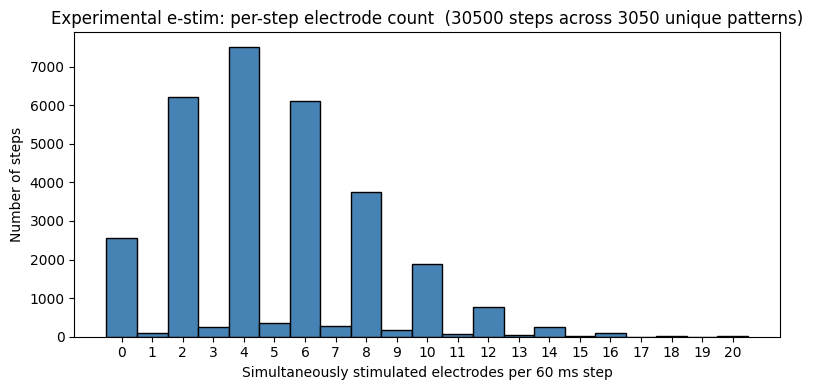

mean = 4.95, median = 4.0, max = 20, n_steps = 30500
(source file has 4000 trial rows, 3050 unique patterns)


In [33]:
# Histogram: number of simultaneously stimulated electrodes per 60 ms step,
# counted across every step of the EXPERIMENT'S e-stim patterns (the ones used
# to train/val/test the model) -- NOT the greedy reconstructions.
# Source: Combined_Pattern_Registrations.pkl.
# "Simultaneous within a step" = unique channels active anywhere in that step
# (NOT per 10 ms bin), so this is just len(step['channel_delays']).
# Deduplicates to unique pattern_name (3100 unique patterns x 10 steps = 31000)
# rather than counting trial replicates.
import pickle
import matplotlib.pyplot as plt

PATTERN_PKL  = f'{datadir}/Combined_Pattern_Registrations.pkl'
DEDUPLICATE  = True  # one entry per unique pattern_name (matches the 3100 figure)

with open(PATTERN_PKL, 'rb') as f:
    experiment_patterns = pickle.load(f)

if DEDUPLICATE:
    seen = {}
    for p in experiment_patterns:
        seen.setdefault(p['pattern_name'], p)
    patterns_to_count = list(seen.values())
else:
    patterns_to_count = experiment_patterns

per_step_counts = np.array([
    len(s['channel_delays'])
    for p in patterns_to_count
    for s in p['steps']
])

max_count = int(per_step_counts.max()) if len(per_step_counts) else 0
bins = np.arange(-0.5, max_count + 1.5, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_step_counts, bins=bins, color='steelblue', edgecolor='black')
ax.set_xlabel('Simultaneously stimulated electrodes per 60 ms step')
ax.set_ylabel('Number of steps')
ax.set_title(f'Experimental e-stim: per-step electrode count  '
             f'({len(per_step_counts)} steps across {len(patterns_to_count)} '
             f'{"unique patterns" if DEDUPLICATE else "trials"})')
ax.set_xticks(np.arange(0, max_count + 1))
plt.tight_layout()
plt.show()

print(f'mean = {per_step_counts.mean():.2f}, median = {np.median(per_step_counts):.1f}, '
      f'max = {per_step_counts.max()}, n_steps = {len(per_step_counts)}')
print(f'(source file has {len(experiment_patterns)} trial rows, '
      f'{len(set(p["pattern_name"] for p in experiment_patterns))} unique patterns)')


In [54]:
# ============================================================
# Merge every generated_pattern_registration_*.pkl in `datadir` (one per
# budget / vis-time exploration) into ONE long registration file with a
# superset of patterns, then write a CSV cross-reference.
#
# Collision handling across files:
#   - pattern_timing_index : re-numbered 1..N contiguously over the merged
#     list (matches the round-trip invariant in the generator cell), so each
#     source file is offset by however many trials preceded it.
#   - pattern_name         : source names look like "50<ori_idx>" and would
#     collide across files, so file k's names are shifted into their own
#     block (name + k * NAME_BLOCK). ori_idx is still recoverable as
#     int(new_name) % NAME_BLOCK, so the orientation lookup keeps working.
#
# Outputs (in `datadir`):
#   merged_pattern_registration.pkl   - superset list, same schema as the
#                                       per-budget files / Combined_*.pkl
#   merged_pattern_xref.csv           - one row per (merged) unique pattern:
#       pattern_name, source_file, source_budget, source_pattern_name,
#       ori_idx, target_orientation_deg, start_timing_index, n_trials, steps_str
# ============================================================
import os, glob, pickle, csv, copy, re
from collections import Counter

NAME_BLOCK = 1000  # per-file pattern-name offset (must exceed max ori_idx)

# Discover the per-budget pkls (exclude the experiment's own reference file
# and any previous merged output).
src_paths = sorted(
    p for p in glob.glob(os.path.join(datadir, 'generated_pattern_registration_*.pkl'))
    if 'merged' not in os.path.basename(p)
)
assert src_paths, f'no generated_pattern_registration_*.pkl found in {datadir}'
print(f'merging {len(src_paths)} file(s):')
for p in src_paths:
    print('  -', os.path.basename(p))

def _budget_method_from_name(fname):
    budget = re.search(r'_(\d+)budget_', fname)
    method = 'pca' if '_pca' in fname else 'lda' if '_lda' in fname else None
    return (int(budget.group(1)) if budget else None, method)

def _steps_to_str(steps):
    """Compact, stable string rendering of a pattern's steps for the xref."""
    parts = []
    for s in steps:
        cds = ';'.join(f"ch{cd['channel']}:dm{cd['delay_mode']}"
                       for cd in s['channel_delays'])
        parts.append(f"[{s['index']}]{cds}")
    return ' | '.join(parts)

merged = []
xref_rows = []
next_timing = 1  # contiguous re-numbering across all files

for file_k, path in enumerate(src_paths):
    with open(path, 'rb') as f:
        patterns = pickle.load(f)
    budget, method = _budget_method_from_name(os.path.basename(path))
    name_shift = file_k * NAME_BLOCK

    seen_order = []
    seen = {}

    for p in patterns:
        q = copy.deepcopy(p)
        src_name = str(p['pattern_name'])
        src_ori_idx = int(src_name[2:])          # names are '50<ori_idx>'  -> strip '50'
        new_ori_idx = src_ori_idx + name_shift   # per-file block to avoid collisions
        new_name = f'50{new_ori_idx}'            # keep the '50<...>' convention
        q['pattern_name'] = new_name
        q['pattern_timing_index'] = next_timing
        next_timing += 1
        merged.append(q)

        if new_name not in seen:
            ori_idx = src_ori_idx                # original ori_idx (recoverable: new % NAME_BLOCK)
            try:
                target_deg = float(visual_orientation_degs[ori_idx])
            except (NameError, IndexError):
                target_deg = ''
            seen[new_name] = dict(
                pattern_name=new_name,
                source_file=os.path.basename(path),
                source_budget=budget if budget is not None else '',
                decomp_method=method if method is not None else '',
                source_pattern_name=src_name,
                ori_idx=ori_idx,
                target_orientation_deg=target_deg,
                start_timing_index=q['pattern_timing_index'],
                n_trials=0,
                steps_str=_steps_to_str(p['steps']),
            )
            seen_order.append(new_name)
        seen[new_name]['n_trials'] += 1

    for nm in seen_order:
        xref_rows.append(seen[nm])


# ---- sanity: contiguous, unique timing indices over the whole merge ----
timing_idxs = [p['pattern_timing_index'] for p in merged]
assert sorted(timing_idxs) == list(range(1, len(merged) + 1)), 'timing idxs not 1..N'
assert len(set(p['pattern_name'] for p in merged)) == len(xref_rows), \
    'pattern_name / xref count mismatch'

# ---- write merged pkl ----
merged_pkl = os.path.join(datadir, 'merged_pattern_registration.pkl')
with open(merged_pkl, 'wb') as f:
    pickle.dump(merged, f)
print(f'\nWrote {len(merged)} trials '
      f'({len(xref_rows)} unique patterns) -> {merged_pkl}')

# ---- schema check against the reference registration ----
ref_path = os.path.join(datadir, 'Combined_Pattern_Registrations.pkl')
if os.path.isfile(ref_path):
    with open(ref_path, 'rb') as f:
        ref = pickle.load(f)
    assert set(ref[0].keys()) == set(merged[0].keys()), 'top-level schema mismatch'
    assert set(ref[0]['steps'][0].keys()) == set(merged[0]['steps'][0].keys()), \
        'step schema mismatch'
    print('[OK] merged schema matches Combined_Pattern_Registrations.pkl')

# ---- write CSV cross-reference ----
xref_csv = os.path.join(datadir, 'merged_pattern_xref.csv')
fieldnames = ['pattern_name', 'source_file', 'source_budget', 'decomp_method', 'source_pattern_name',
              'ori_idx', 'target_orientation_deg', 'start_timing_index',
              'n_trials', 'steps_str']
with open(xref_csv, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(xref_rows)
print(f'Wrote xref for {len(xref_rows)} patterns -> {xref_csv}')

# ---- summary ----
by_file = Counter(r['source_file'] for r in xref_rows)
print('\nunique patterns per source file:')
for fn, c in by_file.items():
    print(f'  {fn}: {c}')

# Optional round-trip through read_pattern_json (kept consistent with the
# generator cell's validation).
try:
    rt_df = read_pattern_json(merged_pkl)
    print(f'[OK] read_pattern_json round-trip: {rt_df.shape[0]} rows, '
          f'{rt_df["pattern_timing_index"].nunique()} timing idxs, '
          f'{rt_df["pattern_name"].nunique()} unique patterns')
except Exception as e:
    print(f'[note] read_pattern_json round-trip skipped: {e}')


merging 8 file(s):
  - generated_pattern_registration_10budget_600ms_lda.pkl
  - generated_pattern_registration_10budget_600ms_pca.pkl
  - generated_pattern_registration_4budget_600ms_lda.pkl
  - generated_pattern_registration_4budget_600ms_pca.pkl
  - generated_pattern_registration_6budget_600ms_lda.pkl
  - generated_pattern_registration_6budget_600ms_pca.pkl
  - generated_pattern_registration_8budget_600ms_lda.pkl
  - generated_pattern_registration_8budget_600ms_pca.pkl

Wrote 128 trials (128 unique patterns) -> data/icms_150_6_2_26/merged_pattern_registration.pkl
[OK] merged schema matches Combined_Pattern_Registrations.pkl
Wrote xref for 128 patterns -> data/icms_150_6_2_26/merged_pattern_xref.csv

unique patterns per source file:
  generated_pattern_registration_10budget_600ms_lda.pkl: 16
  generated_pattern_registration_10budget_600ms_pca.pkl: 16
  generated_pattern_registration_4budget_600ms_lda.pkl: 16
  generated_pattern_registration_4budget_600ms_pca.pkl: 16
  generated_patte